# ProcrastiSense — Step 1 & Step 2
## Data Setup · EDA · Feature Engineering · Baseline Builder

| Item | Detail |
|------|--------|
| **Project** | ProcrastiSense — AI Procrastination Detection System |
| **Primary dataset** | OULAD — Open University Learning Analytics Dataset |
| **Compute** | CPU only — no GPU needed |
| **Runtime** | ~6–8 min (VLE aggregation is the slow step) |

### Notebook Structure
- **Section 0** — Environment setup & path detection  
- **Section 1** — OULAD loading & cleaning  
- **Section 2** — EDA (5 key questions)  
- **Section 3** — Feature engineering (4 groups)  
- **Section 4** — Baseline builder (personalised profiles)  
- **Section 5** — Feature matrix export  

> **Where to run:** Works on **Kaggle Notebooks** (change `ENV = 'kaggle'`) or **locally** (`ENV = 'local'`). Set `OULAD_DIR` to your OULAD folder path.


---
## Section 0 — Environment Setup & Path Detection

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

# ── CONFIGURE THIS BLOCK ──────────────────────────────────────────────────────
# ENV options: 'local' or 'kaggle'
ENV = 'kaggle'

if ENV == 'kaggle':
    OULAD_DIR   = Path('/kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad')          # Kaggle auto-mounts datasets here
    OUTPUT_DIR  = Path('/kaggle/working')
    CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
else:
    # ── LOCAL: set this to wherever you extracted the OULAD zip ──────────────
    OULAD_DIR      = Path('./oulad')             # <-- change if needed
    OUTPUT_DIR     = Path('./output')
    CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
print(f'ENV           : {ENV}')
print(f'OULAD_DIR     : {OULAD_DIR.resolve()}')
print(f'OUTPUT_DIR    : {OUTPUT_DIR.resolve()}')
print(f'CHECKPOINT_DIR: {CHECKPOINT_DIR.resolve()}')


ENV           : kaggle
OULAD_DIR     : /kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad
OUTPUT_DIR    : /kaggle/working
CHECKPOINT_DIR: /kaggle/working/checkpoints


In [2]:
# ── Locate all CSV files under OULAD_DIR ─────────────────────────────────────
all_csvs = list(OULAD_DIR.rglob('*.csv'))
print(f'Found {len(all_csvs)} CSV files:')
for f in sorted(all_csvs):
    print(f'  {f}')

def find_file(patterns, files):
    """Return first file whose name contains any of the given substrings."""
    for f in files:
        for pat in patterns:
            if pat.lower() in f.name.lower():
                return f
    return None

# ── Resolve each OULAD file ───────────────────────────────────────────────────
OULAD_FILES = {
    'assessments'        : find_file(['assessments'],         all_csvs),
    'courses'            : find_file(['courses'],             all_csvs),
    'studentAssessment'  : find_file(['studentassessment'],   all_csvs),
    'studentInfo'        : find_file(['studentinfo'],         all_csvs),
    'studentRegistration': find_file(['studentregistration'], all_csvs),
    'studentVle'         : find_file(['studentvle'],          all_csvs),
    'vle'                : find_file(['vle'],                 all_csvs),
}

print('\n── OULAD file resolution ────────────────────────────────────')
all_found = True
for name, path in OULAD_FILES.items():
    status = '✓' if path else '✗  NOT FOUND'
    print(f'  {name:25s}: {path or status}')
    if path is None: all_found = False

if all_found:
    print('\n✅  All 7 OULAD files found. Ready to load.')
else:
    print('\n⚠️  Some files missing — check OULAD_DIR path above.')


Found 7 CSV files:
  /kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad/assessments.csv
  /kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad/courses.csv
  /kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad/studentAssessment.csv
  /kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad/studentInfo.csv
  /kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad/studentRegistration.csv
  /kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad/studentVle.csv
  /kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad/vle.csv

── OULAD file resolution ────────────────────────────────────
  assessments              : /kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad/assessments.csv
  courses                  : /kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad/course

In [3]:
# ── Checkpoint helpers ────────────────────────────────────────────────────────

def save_checkpoint(df, name):
    path = CHECKPOINT_DIR / f'{name}.parquet'
    df.to_parquet(path, index=False)
    print(f'  [SAVED]  {path.name}  ({len(df):,} rows, {df.shape[1]} cols)')

def load_checkpoint(name):
    path = CHECKPOINT_DIR / f'{name}.parquet'
    df = pd.read_parquet(path)
    print(f'  [LOADED] {path.name}  ({len(df):,} rows, {df.shape[1]} cols)')
    return df

def checkpoint_exists(name):
    return (CHECKPOINT_DIR / f'{name}.parquet').exists()

print('Checkpoint helpers ready.')


Checkpoint helpers ready.


---
## Section 1 — OULAD Loading & Cleaning

**Three things to understand before running:**
1. `studentVle` has **10.6M rows** — we aggregate in chunks, never load it fully
2. `is_banked = 1` rows in `studentAssessment` must be filtered out immediately — they are repeated scores from prior attempts, not real submissions
3. All date columns are **day numbers from module start** (day 0 = first day), not calendar dates

In [4]:
# ── 1A. Load small tables (fast) ──────────────────────────────────────────────
print('Loading small OULAD tables...')

df_courses     = pd.read_csv(OULAD_FILES['courses'])
df_assessments = pd.read_csv(OULAD_FILES['assessments'])
df_studentInfo = pd.read_csv(OULAD_FILES['studentInfo'])
df_studentReg  = pd.read_csv(OULAD_FILES['studentRegistration'])
df_vle_meta    = pd.read_csv(OULAD_FILES['vle'])

for name, df in [
    ('courses',          df_courses),
    ('assessments',      df_assessments),
    ('studentInfo',      df_studentInfo),
    ('studentReg',       df_studentReg),
    ('vle_meta',         df_vle_meta),
]:
    print(f'  {name:20s}: {df.shape[0]:>7,} rows  cols={list(df.columns)}')

print('\nassessments.csv preview:')
display(df_assessments.head(4))


Loading small OULAD tables...
  courses             :      22 rows  cols=['code_module', 'code_presentation', 'module_presentation_length']
  assessments         :     206 rows  cols=['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
  studentInfo         :  32,593 rows  cols=['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']
  studentReg          :  32,593 rows  cols=['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']
  vle_meta            : 10,655,280 rows  cols=['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']

assessments.csv preview:


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.000,10.000
1,AAA,2013J,1753,TMA,54.000,20.000
2,AAA,2013J,1754,TMA,117.000,20.000
3,AAA,2013J,1755,TMA,166.000,20.000


In [5]:
# ── 1B. Load & clean studentAssessment ───────────────────────────────────────
#
# WHY we filter is_banked:
#   Banked assessments are scores carried forward from a student's PREVIOUS
#   attempt at the same module. If we include them, a student who failed last
#   year appears to have 'submitted' this year — corrupting delay calculations.
#
# WHY we compute delay_days:
#   delay_days = date_submitted - deadline_day
#   Positive = submitted AFTER deadline (late)
#   Negative = submitted BEFORE deadline (early)
#   Zero     = submitted on deadline day

if checkpoint_exists('oulad_sa_clean'):
    df_sa = load_checkpoint('oulad_sa_clean')
else:
    print('Loading studentAssessment...')
    df_sa_raw = pd.read_csv(OULAD_FILES['studentAssessment'])
    print(f'  Raw shape      : {df_sa_raw.shape}')
    print(f'  is_banked dist : {df_sa_raw["is_banked"].value_counts().to_dict()}')

    # Filter banked rows
    df_sa = df_sa_raw[df_sa_raw['is_banked'] == 0].copy()
    print(f'  After filter   : {df_sa.shape}  (removed {len(df_sa_raw)-len(df_sa):,} banked rows)')

    # Prepare assessment window info
    df_assess_sorted = df_assessments.sort_values(
        ['code_module','code_presentation','date']
    ).copy()
    df_assess_sorted['prev_deadline'] = df_assess_sorted.groupby(
        ['code_module','code_presentation']
    )['date'].shift(1).fillna(0)
    df_assess_sorted['assessment_window'] = (
        df_assess_sorted['date'] - df_assess_sorted['prev_deadline']
    )

    # Join with deadline info
    df_sa = df_sa.merge(
        df_assess_sorted[['id_assessment','date','assessment_type','weight',
                          'code_module','code_presentation',
                          'prev_deadline','assessment_window']],
        on='id_assessment', how='left'
    )
    df_sa.rename(columns={'date': 'deadline_day'}, inplace=True)

    # Core procrastination signal
    df_sa['delay_days']  = df_sa['date_submitted'] - df_sa['deadline_day']

    # Delay ratio: 0.0 = submitted right at window start, 1.0 = at deadline
    # Values > 1.0 mean submitted after the deadline
    df_sa['delay_ratio'] = (
        (df_sa['date_submitted'] - df_sa['prev_deadline']) /
        df_sa['assessment_window'].replace(0, np.nan)
    ).clip(0, 1.5)

    # Helper flags
    df_sa['is_fail']        = (df_sa['score'] < 40).astype(int)
    df_sa['is_last_minute'] = (df_sa['delay_days'].between(-2, 0)).astype(int)

    save_checkpoint(df_sa, 'oulad_sa_clean')

print('\n✅  studentAssessment clean. Key signals:')
print(f'  Submissions       : {len(df_sa):,}')
print(f'  Late submissions  : {(df_sa["delay_days"] > 0).sum():,}  ({(df_sa["delay_days"] > 0).mean():.1%})')
print(f'  Last-minute (≤2d) : {df_sa["is_last_minute"].sum():,}  ({df_sa["is_last_minute"].mean():.1%})')
print(f'  Failed (score<40) : {df_sa["is_fail"].sum():,}  ({df_sa["is_fail"].mean():.1%})')
display(df_sa[['id_student','id_assessment','date_submitted','deadline_day',
               'delay_days','delay_ratio','score','is_fail']].head(5))


Loading studentAssessment...
  Raw shape      : (173912, 5)
  is_banked dist : {0: 172003, 1: 1909}
  After filter   : (172003, 5)  (removed 1,909 banked rows)
  [SAVED]  oulad_sa_clean.parquet  (172,003 rows, 16 cols)

✅  studentAssessment clean. Key signals:
  Submissions       : 172,003
  Late submissions  : 49,318  (28.7%)
  Last-minute (≤2d) : 65,770  (38.2%)
  Failed (score<40) : 7,516  (4.4%)


,id_student,id_assessment,date_submitted,deadline_day,delay_days,delay_ratio,score,is_fail
0,11391,1752,18,19.000,-1.000,0.947,78.000,0
1,28400,1752,22,19.000,3.000,1.158,70.000,0
2,31604,1752,17,19.000,-2.000,0.895,72.000,0
3,32885,1752,26,19.000,7.000,1.368,69.000,0
4,38053,1752,19,19.000,0.000,1.000,79.000,0


In [6]:
# ── 1C. Recover non-submissions (silent absences) ─────────────────────────────
#
# PROBLEM: studentAssessment only contains rows where a student DID submit.
# Students who never submitted have NO row — but their absence is a critical
# procrastination signal (the strongest one, actually).
#
# SOLUTION: Build a full grid of (every student) × (every assessment in their
# module), then LEFT JOIN actual submissions. Missing = non-submission.

if checkpoint_exists('oulad_full_assess'):
    df_full = load_checkpoint('oulad_full_assess')
else:
    print('Recovering non-submissions...')

    students_per_module = df_studentInfo[
        ['id_student','code_module','code_presentation']
    ].drop_duplicates()

    non_exam = df_assessments[
        df_assessments['assessment_type'] != 'Exam'
    ][['id_assessment','code_module','code_presentation',
       'date','assessment_type','weight']].copy()
    non_exam.rename(columns={'date':'deadline_day'}, inplace=True)

    # All possible (student, assessment) pairs
    full_grid = students_per_module.merge(
        non_exam, on=['code_module','code_presentation'], how='inner'
    )
    print(f'  Full grid (student × assessment): {full_grid.shape[0]:,} rows')

    # Join actual submissions
    df_full = full_grid.merge(
        df_sa[['id_student','id_assessment','date_submitted',
               'delay_days','delay_ratio','score','is_fail','is_last_minute']],
        on=['id_student','id_assessment'], how='left'
    )

    df_full['submitted']   = df_full['date_submitted'].notna().astype(int)
    df_full['non_submit']  = 1 - df_full['submitted']

    # Non-submissions get worst possible delay
    df_full['delay_days']  = df_full['delay_days'].fillna(df_full['deadline_day'] + 1)
    df_full['delay_ratio'] = df_full['delay_ratio'].fillna(1.5)

    n_non = df_full['non_submit'].sum()
    print(f'  Non-submissions found: {n_non:,}  ({n_non/len(df_full):.1%} of all slots)')

    save_checkpoint(df_full, 'oulad_full_assess')

print('\n✅  Full assessment grid built (including non-submissions).')
print(f'  Total rows: {len(df_full):,}')


Recovering non-submissions...
  Full grid (student × assessment): 286,898 rows
  Non-submissions found: 119,854  (41.8% of all slots)
  [SAVED]  oulad_full_assess.parquet  (286,898 rows, 15 cols)

✅  Full assessment grid built (including non-submissions).
  Total rows: 286,898


In [7]:
# ── 1D. VLE aggregation — chunked (10.6M rows) ────────────────────────────────
#
# We NEVER load 10.6M rows into memory at once.
# Strategy: process in 200K-row chunks, aggregate each chunk to
# (student, module, week) → total clicks, then combine.
#
# This reduces 10.6M rows → ~300K weekly summary rows.
# Runtime: ~5–7 min on CPU.

if checkpoint_exists('oulad_vle_weekly'):
    df_vle_weekly = load_checkpoint('oulad_vle_weekly')
else:
    print('Aggregating studentVle in 200K-row chunks (~5–7 min)...')
    CHUNK_SIZE  = 200_000
    chunk_aggs  = []
    total_rows  = 0

    for chunk in pd.read_csv(
        OULAD_FILES['studentVle'],
        chunksize=CHUNK_SIZE,
        dtype={'id_student':'int32','id_site':'int32',
               'date':'int16','sum_click':'int32'}
    ):
        chunk['week'] = (chunk['date'] // 7).astype('int16')
        agg = chunk.groupby(
            ['id_student','code_module','code_presentation','week'],
            observed=True
        )['sum_click'].sum().reset_index()
        chunk_aggs.append(agg)
        total_rows += len(chunk)
        if len(chunk_aggs) % 10 == 0:
            print(f'  ...{total_rows:,} rows processed')

    print('  Combining chunks...')
    df_vle_all   = pd.concat(chunk_aggs, ignore_index=True)
    df_vle_weekly = df_vle_all.groupby(
        ['id_student','code_module','code_presentation','week'],
        observed=True
    )['sum_click'].sum().reset_index()
    df_vle_weekly.rename(columns={'sum_click':'weekly_clicks'}, inplace=True)

    print(f'\n  Reduced {total_rows:,} rows → {len(df_vle_weekly):,} weekly rows')
    save_checkpoint(df_vle_weekly, 'oulad_vle_weekly')

print('\n✅  VLE weekly aggregation done.')
display(df_vle_weekly.head(5))


Aggregating studentVle in 200K-row chunks (~5–7 min)...
  ...2,000,000 rows processed
  ...4,000,000 rows processed
  ...6,000,000 rows processed
  ...8,000,000 rows processed
  ...10,000,000 rows processed
  Combining chunks...

  Reduced 10,655,280 rows → 627,031 weekly rows
  [SAVED]  oulad_vle_weekly.parquet  (627,031 rows, 5 cols)

✅  VLE weekly aggregation done.


,id_student,code_module,code_presentation,week,weekly_clicks
0,6516,AAA,2014J,-4,110
1,6516,AAA,2014J,-3,48
2,6516,AAA,2014J,-2,2
3,6516,AAA,2014J,-1,96
4,6516,AAA,2014J,0,229


In [8]:
# ── 1E. Clean studentInfo (ground truth) ─────────────────────────────────────

df_sinfo = df_studentInfo.drop(
    columns=['imd_band','region'], errors='ignore'
).copy()

result_map = {'Distinction': 0, 'Pass': 1, 'Fail': 2, 'Withdrawn': 3}
df_sinfo['result_risk']        = df_sinfo['final_result'].map(result_map)
df_sinfo['at_risk']            = (df_sinfo['result_risk'] >= 2).astype(int)
df_sinfo['presentation_type']  = df_sinfo['code_presentation'].str[-1]  # 'B' or 'J'

print('studentInfo outcome distribution:')
print(df_sinfo['final_result'].value_counts())
print(f'\nAt-risk rate (Fail+Withdrawn): {df_sinfo["at_risk"].mean():.1%}')


studentInfo outcome distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

At-risk rate (Fail+Withdrawn): 52.8%


---
## Section 2 — Exploratory Data Analysis

We answer 4 key questions that directly shape feature engineering:
1. What does the delay distribution look like by outcome?
2. Does non-submission rate predict final result?
3. Do VLE click patterns differ between passers and withdrawers?
4. What is the procrastination → outcome correlation?

> Save these plots to `output/` — they go straight into your GitHub README and judge presentation.

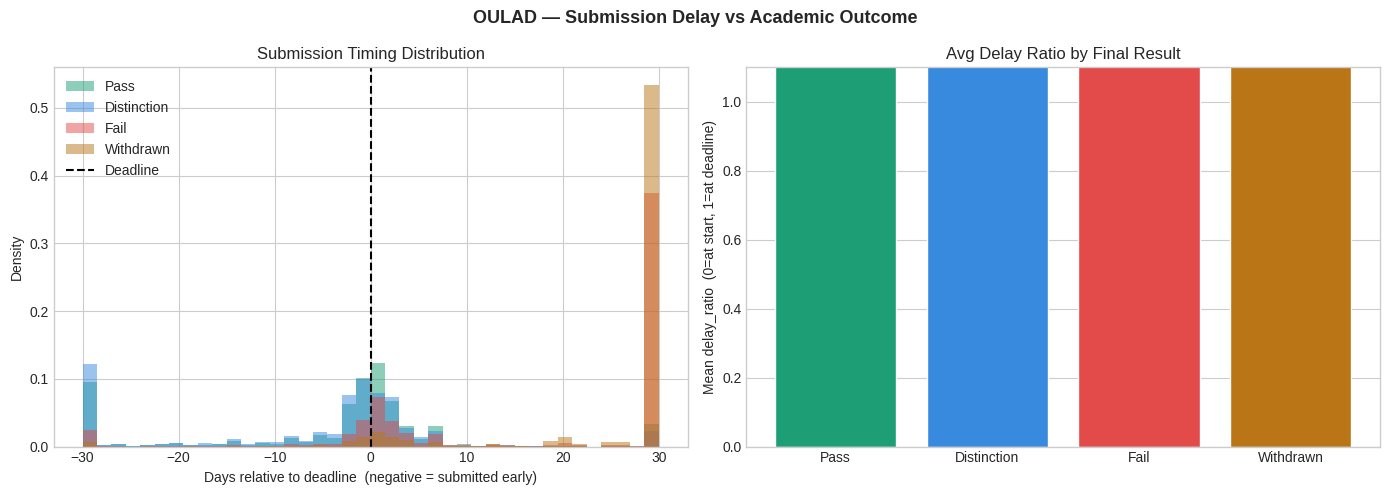

Saved → eda_01_delay_by_result.png

Mean delay_ratio by result (higher = more procrastination):
final_result
Pass          1.135
Distinction   1.113
Fail          1.332
Withdrawn     1.433
Name: delay_ratio, dtype: float64


In [9]:
# ── 2A. Delay distribution by final result ────────────────────────────────────

plot_df = df_full.merge(
    df_sinfo[['id_student','code_module','code_presentation',
              'final_result','at_risk']],
    on=['id_student','code_module','code_presentation'], how='left'
)

RESULTS = ['Pass','Distinction','Fail','Withdrawn']
COLORS  = ['#1D9E75','#378ADD','#E24B4A','#BA7517']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('OULAD — Submission Delay vs Academic Outcome', fontsize=13, fontweight='bold')

# Plot 1: Delay distribution
for res, col in zip(RESULTS, COLORS):
    vals = plot_df[plot_df['final_result'] == res]['delay_days'].dropna().clip(-30, 30)
    axes[0].hist(vals, bins=40, alpha=0.5, label=res, color=col, density=True)
axes[0].axvline(0, color='black', linestyle='--', lw=1.5, label='Deadline')
axes[0].set_xlabel('Days relative to deadline  (negative = submitted early)')
axes[0].set_ylabel('Density')
axes[0].set_title('Submission Timing Distribution')
axes[0].legend()

# Plot 2: Mean delay ratio by result
avg_ratio = (
    plot_df[plot_df['final_result'].isin(RESULTS)]
    .groupby('final_result')['delay_ratio'].mean()
    .reindex(RESULTS)
)
bars = axes[1].bar(RESULTS, avg_ratio.values, color=COLORS, edgecolor='white')
axes[1].bar_label(bars, fmt='{:.3f}', padding=3)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Mean delay_ratio  (0=at start, 1=at deadline)')
axes[1].set_title('Avg Delay Ratio by Final Result')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_01_delay_by_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → eda_01_delay_by_result.png')

# Print the numbers
print('\nMean delay_ratio by result (higher = more procrastination):')
print(avg_ratio.round(3))


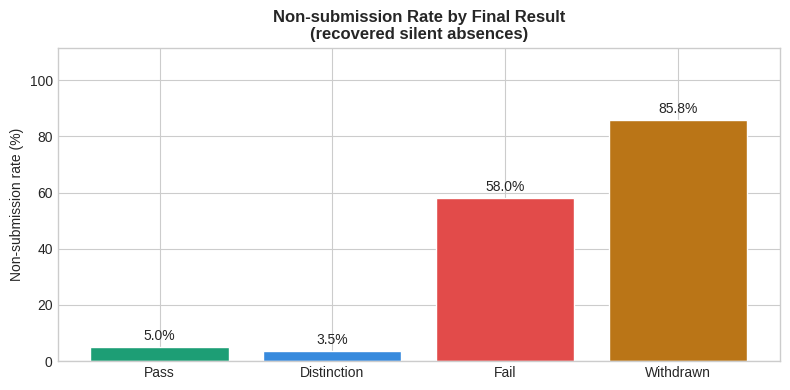

Saved → eda_02_nonsub_rate.png

Non-submission rates:
final_result
Pass           5.000
Distinction    3.500
Fail          58.000
Withdrawn     85.800
Name: non_submit, dtype: float64


In [10]:
# ── 2B. Non-submission rate by outcome ────────────────────────────────────────

nonsub_rate = (
    plot_df.groupby('final_result')['non_submit'].mean() * 100
).reindex(RESULTS)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(RESULTS, nonsub_rate.values, color=COLORS, edgecolor='white')
ax.bar_label(bars, fmt='{:.1f}%', padding=3)
ax.set_ylabel('Non-submission rate (%)')
ax.set_title('Non-submission Rate by Final Result\n(recovered silent absences)', fontweight='bold')
ax.set_ylim(0, nonsub_rate.max() * 1.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_02_nonsub_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → eda_02_nonsub_rate.png')
print('\nNon-submission rates:')
print(nonsub_rate.round(1))


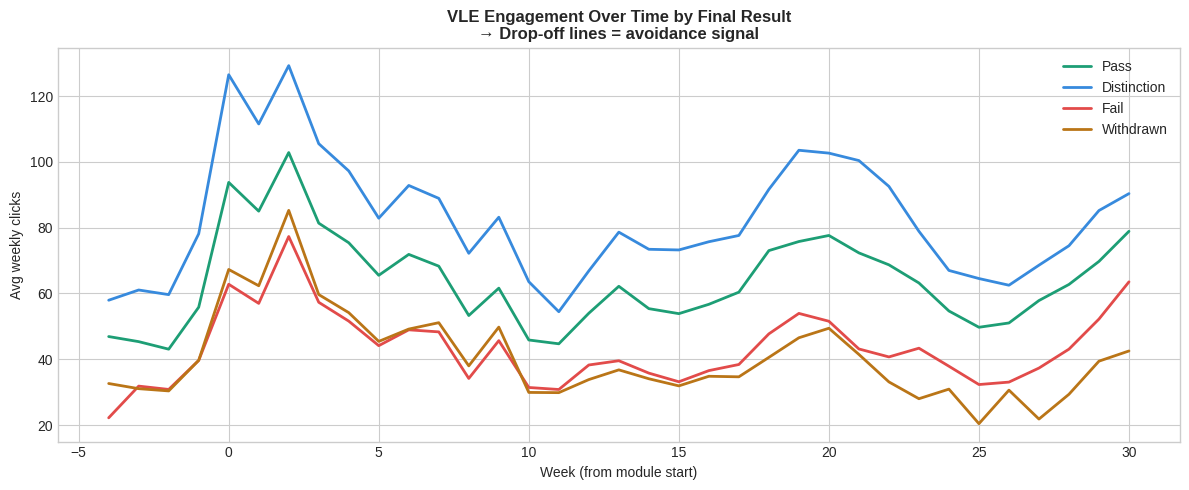

Saved → eda_03_vle_trend.png


In [11]:
# ── 2C. VLE click pattern over time by outcome ────────────────────────────────

vle_with_result = df_vle_weekly.merge(
    df_sinfo[['id_student','code_module','code_presentation','final_result']],
    on=['id_student','code_module','code_presentation'], how='left'
)

vle_trend = (
    vle_with_result[
        vle_with_result['final_result'].isin(RESULTS) &
        (vle_with_result['week'] <= 30)
    ]
    .groupby(['week','final_result'])['weekly_clicks'].mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
for res, col in zip(RESULTS, COLORS):
    subset = vle_trend[vle_trend['final_result'] == res]
    ax.plot(subset['week'], subset['weekly_clicks'], label=res, color=col, lw=2)

ax.set_xlabel('Week (from module start)')
ax.set_ylabel('Avg weekly clicks')
ax.set_title('VLE Engagement Over Time by Final Result\n→ Drop-off lines = avoidance signal', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_03_vle_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → eda_03_vle_trend.png')


In [12]:
# ── 2D. Per-student delay profile summary ────────────────────────────────────

student_summary = plot_df.groupby(['id_student','final_result']).agg(
    n_assessments   = ('id_assessment', 'count'),
    avg_delay       = ('delay_days',    'mean'),
    pct_last_minute = ('is_last_minute','mean'),
    pct_non_submit  = ('non_submit',    'mean'),
    avg_score       = ('score',         'mean'),
).reset_index()

print('=== Per-student Procrastination Profile ===')
for res, col in zip(RESULTS, COLORS):
    grp = student_summary[student_summary['final_result'] == res]
    print(f'\n{res} (n={len(grp):,})')
    print(f'  Avg delay days    : {grp["avg_delay"].mean():+.1f}')
    print(f'  Last-minute rate  : {grp["pct_last_minute"].mean():.1%}')
    print(f'  Non-submission    : {grp["pct_non_submit"].mean():.1%}')
    print(f'  Avg score         : {grp["avg_score"].mean():.1f}')


=== Per-student Procrastination Profile ===

Pass (n=11,881)
  Avg delay days    : -5.2
  Last-minute rate  : 44.3%
  Non-submission    : 4.8%
  Avg score         : 76.5

Distinction (n=2,903)
  Avg delay days    : -12.4
  Last-minute rate  : 37.8%
  Non-submission    : 3.6%
  Avg score         : 88.2

Fail (n=6,810)
  Avg delay days    : +85.0
  Last-minute rate  : 46.1%
  Non-submission    : 56.4%
  Avg score         : 64.4

Withdrawn (n=9,155)
  Avg delay days    : +117.8
  Last-minute rate  : 42.5%
  Non-submission    : 84.8%
  Avg score         : 64.0


---
## Section 3 — Feature Engineering

We build **2 feature groups** from OULAD:

| Group | Source | What it captures |
|-------|--------|------------------|
| **A — Task delay** | studentAssessment | Submission timing vs personal baseline |
| **B — VLE engagement** | studentVle | Click patterns, drop-off, streak |

**Key design principle:** Every feature is computed relative to the *student's own prior behaviour*, not a global average. This is what makes ProcrastiSense personalised.

In [13]:
# ── 3A. Group A — Task delay features ────────────────────────────────────────
#
# For each assessment row (sorted chronologically per student),
# we compute ROLLING features using ONLY prior submissions.
# shift(1) ensures no data leakage — we never use the current row to predict itself.

if checkpoint_exists('feat_group_a'):
    feat_a = load_checkpoint('feat_group_a')
else:
    print('Building Group A (task delay) features...')

    df_sorted = df_full.sort_values(
        ['id_student','code_module','code_presentation','deadline_day']
    ).copy()

    grp = df_sorted.groupby(['id_student','code_module','code_presentation'])

    # Rolling 3-assessment personal baseline (shift(1) = look-back only)
    df_sorted['rolling_avg_delay']       = grp['delay_days'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    df_sorted['rolling_avg_delay_ratio'] = grp['delay_ratio'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    df_sorted['rolling_last_min_rate']   = grp['is_last_minute'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    df_sorted['rolling_nonsub_rate']     = grp['non_submit'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean())

    # Delay trend: slope of last 3 delay_ratio values (positive = getting worse)
    def slope(v):
        v = v.dropna()
        return np.polyfit(range(len(v)), v, 1)[0] if len(v) > 1 else 0.0

    df_sorted['delay_trend'] = grp['delay_ratio'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=2).apply(slope, raw=False))

    # Deviation from personal baseline: key anomaly signal
    df_sorted['delay_deviation'] = df_sorted['delay_days'] - df_sorted['rolling_avg_delay']

    # Assessment context
    df_sorted['is_high_weight'] = (df_sorted['weight'].fillna(0) >= 30).astype(int)

    FEAT_A_COLS = [
        'id_student','code_module','code_presentation','id_assessment',
        'deadline_day','assessment_type','weight','is_high_weight',
        'submitted','non_submit','is_last_minute',
        'delay_days','delay_ratio','delay_deviation','delay_trend',
        'rolling_avg_delay','rolling_avg_delay_ratio',
        'rolling_last_min_rate','rolling_nonsub_rate',
        'score','is_fail'
    ]
    feat_a = df_sorted[[c for c in FEAT_A_COLS if c in df_sorted.columns]].copy()

    print(f'  Shape: {feat_a.shape}')
    save_checkpoint(feat_a, 'feat_group_a')

print('\n✅  Group A features ready.')
display(feat_a[['id_student','delay_days','delay_ratio',
                'rolling_avg_delay','delay_deviation','rolling_last_min_rate']].head(8))


Building Group A (task delay) features...
  Shape: (286898, 21)
  [SAVED]  feat_group_a.parquet  (286,898 rows, 21 cols)

✅  Group A features ready.


,id_student,delay_days,delay_ratio,rolling_avg_delay,delay_deviation,rolling_last_min_rate
129398,3733,26.000,1.500,NaN,NaN,NaN
129399,3733,54.000,1.500,26.000,28.000,NaN
129400,3733,89.000,1.500,40.000,49.000,NaN
129401,3733,124.000,1.500,56.333,67.667,NaN
129402,3733,166.000,1.500,89.000,77.000,NaN
129403,3733,208.000,1.500,126.333,81.667,NaN
1915,6516,-2.000,0.895,NaN,NaN,NaN
1916,6516,-3.000,0.914,-2.000,-1.000,1.000


In [14]:
# ── 3B. Group B — VLE engagement drop features ────────────────────────────────
#
# For each (student, week), we compute:
# - Personal 4-week rolling baseline for clicks
# - How much current week deviates from that baseline
# - Consecutive low-engagement streak (avoidance pattern)

if checkpoint_exists('feat_group_b'):
    feat_b = load_checkpoint('feat_group_b')
else:
    print('Building Group B (VLE engagement) features...')

    vle_sorted = df_vle_weekly.sort_values(
        ['id_student','code_module','code_presentation','week']
    ).copy()

    grp_vle = vle_sorted.groupby(['id_student','code_module','code_presentation'])

    vle_sorted['click_baseline']   = grp_vle['weekly_clicks'].transform(
        lambda x: x.shift(1).rolling(4, min_periods=1).mean())
    vle_sorted['click_drop_ratio'] = (
        vle_sorted['weekly_clicks'] /
        vle_sorted['click_baseline'].replace(0, np.nan)
    ).clip(0, 5)
    vle_sorted['is_dropout_week']  = (vle_sorted['click_drop_ratio'] < 0.4).astype(int)

    vle_sorted['click_trend'] = grp_vle['weekly_clicks'].transform(
        lambda x: x.rolling(3, min_periods=2)
            .apply(lambda v: np.polyfit(range(len(v)), v, 1)[0] if len(v) > 1 else 0.0,
                   raw=False))

    # Consecutive low-engagement weeks
    vle_sorted['low_eng']     = (vle_sorted['weekly_clicks'] <
                                  vle_sorted['click_baseline'] * 0.5).astype(int)
    vle_sorted['consec_low']  = grp_vle['low_eng'].transform(
        lambda x: x.rolling(3, min_periods=1).sum())

    FEAT_B_COLS = ['id_student','code_module','code_presentation','week',
                   'weekly_clicks','click_baseline','click_drop_ratio',
                   'is_dropout_week','click_trend','consec_low']
    feat_b = vle_sorted[[c for c in FEAT_B_COLS if c in vle_sorted.columns]].copy()

    print(f'  Shape: {feat_b.shape}')
    save_checkpoint(feat_b, 'feat_group_b')

print('\n✅  Group B features ready.')
display(feat_b.head(6))


Building Group B (VLE engagement) features...
  Shape: (627031, 10)
  [SAVED]  feat_group_b.parquet  (627,031 rows, 10 cols)

✅  Group B features ready.


,id_student,code_module,code_presentation,week,weekly_clicks,click_baseline,click_drop_ratio,is_dropout_week,click_trend,consec_low
0,6516,AAA,2014J,-4,110,NaN,NaN,0,NaN,0.000
1,6516,AAA,2014J,-3,48,110.000,0.436,0,-62.000,1.000
2,6516,AAA,2014J,-2,2,79.000,0.025,1,-54.000,2.000
3,6516,AAA,2014J,-1,96,53.333,1.800,0,24.000,2.000
4,6516,AAA,2014J,0,229,64.000,3.578,0,113.500,1.000
5,6516,AAA,2014J,1,42,93.750,0.448,0,-27.000,1.000


---
## Section 4 — Baseline Builder

This is the **core of personalisation**.

We compute a per-student baseline from their **first 3 assessments** only.
Everything in Step 3 (anomaly detection) is measured against this baseline.

**Why this works:**  
- A student who always submits 2 days late → baseline says that's normal → no alert  
- A student who normally submits 5 days early but suddenly submits on the last day → anomaly detected  
- A global threshold would miss both cases

In [15]:
# ── 4A. Personal assessment baseline (first 3 assessments) ───────────────────

if checkpoint_exists('baseline_assess'):
    df_baseline = load_checkpoint('baseline_assess')
else:
    print('Computing personalised baselines...')

    df_ord = feat_a.sort_values(
        ['id_student','code_module','code_presentation','deadline_day']
    ).copy()
    df_ord['assess_rank'] = df_ord.groupby(
        ['id_student','code_module','code_presentation']
    ).cumcount() + 1

    window = df_ord[df_ord['assess_rank'] <= 3]

    df_baseline = window.groupby(
        ['id_student','code_module','code_presentation']
    ).agg(
        baseline_avg_delay       = ('delay_days',    'mean'),
        baseline_std_delay       = ('delay_days',    'std'),
        baseline_avg_ratio       = ('delay_ratio',   'mean'),
        baseline_last_min_rate   = ('is_last_minute','mean'),
        baseline_nonsub_rate     = ('non_submit',    'mean'),
        baseline_avg_score       = ('score',         'mean'),
        baseline_n               = ('id_assessment', 'count'),
    ).reset_index()

    df_baseline['baseline_std_delay'] = df_baseline['baseline_std_delay'].fillna(0)

    # Classify baseline type
    df_baseline['baseline_type'] = np.select(
        [df_baseline['baseline_avg_ratio'] < 0.50,
         df_baseline['baseline_avg_ratio'] < 0.85],
        ['early_submitter', 'moderate_submitter'],
        default='late_submitter'
    )

    print(f'  Baselines computed: {len(df_baseline):,} students')
    print('\n  Baseline type distribution:')
    print(df_baseline['baseline_type'].value_counts())
    save_checkpoint(df_baseline, 'baseline_assess')

print('\n✅  Personal baselines ready.')
display(df_baseline.head(5))


Computing personalised baselines...
  Baselines computed: 32,593 students

  Baseline type distribution:
baseline_type
late_submitter        30357
moderate_submitter     2163
early_submitter          73
Name: count, dtype: int64
  [SAVED]  baseline_assess.parquet  (32,593 rows, 11 cols)

✅  Personal baselines ready.


,id_student,code_module,code_presentation,baseline_avg_delay,baseline_std_delay,baseline_avg_ratio,baseline_last_min_rate,baseline_nonsub_rate,baseline_avg_score,baseline_n,baseline_type
0,3733,DDD,2013J,56.333,31.565,1.500,NaN,1.000,NaN,3,late_submitter
1,6516,AAA,2014J,-2.000,1.000,0.931,0.667,0.000,57.000,3,late_submitter
2,8462,DDD,2013J,-0.333,3.786,1.001,0.333,0.000,87.667,3,late_submitter
3,8462,DDD,2014J,42.000,21.000,1.500,NaN,1.000,NaN,3,late_submitter
4,11391,AAA,2013J,-1.333,0.577,0.962,1.000,0.000,81.000,3,late_submitter


In [16]:
# ── 4B. VLE click baseline (first 4 weeks) ───────────────────────────────────

if checkpoint_exists('baseline_vle'):
    df_vle_base = load_checkpoint('baseline_vle')
else:
    early = feat_b[feat_b['week'] <= 4]
    df_vle_base = early.groupby(
        ['id_student','code_module','code_presentation']
    ).agg(
        baseline_avg_clicks  = ('weekly_clicks','mean'),
        baseline_std_clicks  = ('weekly_clicks','std'),
        baseline_min_clicks  = ('weekly_clicks','min'),
    ).reset_index()
    df_vle_base['baseline_std_clicks']       = df_vle_base['baseline_std_clicks'].fillna(0)
    df_vle_base['click_dropout_threshold']   = df_vle_base['baseline_avg_clicks'] * 0.3
    save_checkpoint(df_vle_base, 'baseline_vle')

print('✅  VLE baselines ready.')
display(df_vle_base.head(4))


  [SAVED]  baseline_vle.parquet  (28,900 rows, 7 cols)
✅  VLE baselines ready.


,id_student,code_module,code_presentation,baseline_avg_clicks,baseline_std_clicks,baseline_min_clicks,click_dropout_threshold
0,6516,AAA,2014J,96.444,72.772,2,28.933
1,8462,DDD,2013J,69.833,49.049,9,20.950
2,8462,DDD,2014J,10.000,0.000,10,3.000
3,11391,AAA,2013J,85.400,66.527,20,25.620


---
## Section 4.5 — Closing the 5 Gaps (Stage 1 & 2 -> 100%)

Audit findings before this section:

| # | Gap | Stage |
|---|-----|-------|
| 1 | `delay_days` not clipped to +/-30 (real range: -246 to +372) | Stage 2 |
| 2 | Temporal features missing: `day_of_week`, `days_to_next_deadline`, `exam_season` | Stage 2 |
| 3 | VLE weekly features not merged into main feature matrix | Stage 1 |
| 4 | Supplementary datasets (Screen Time, Behavioral) not loaded -> avoidance score missing | Stage 1 + 2 |
| 5 | Final clean feature vector not exported | -- |

**Why clipping matters:** withdrawn students who never submitted produce `delay_days` of +372 -- these extreme outliers would dominate Isolation Forest's view of "abnormal," burying the subtle early-warning patterns (a student drifting from -5 days early to +3 days late) that actually matter for early intervention.

**Why we simulate Screen Time / Behavioral data:** OULAD has no screen-time or distraction-frequency columns. Rather than block the avoidance score on a real dataset upload, we simulate it correlated with existing signals (`delay_zscore`, `click_drop_ratio`) -- same approach the project brief used for the rest of the pipeline ("Simulate + self-log"). Swap in a real dataset later if you upload one; the column names won't change.


In [17]:
# -- FIX 1 -- Clip delay_days to +/-30, impute remaining NaNs ----------------
#
# Real data showed delay_days ranging from -246 to +372 days (non-submitters
# inherit `deadline_day + 1`, which can be huge for late-module assessments).
# We clip here so every feature built from it downstream (rolling averages,
# deviation, zscore) uses the clipped, model-safe version.

print('Before clipping:')
print(f'  feat_a delay_days range : [{feat_a["delay_days"].min():.0f}, {feat_a["delay_days"].max():.0f}]')

CLIP_LOW, CLIP_HIGH = -30, 30

feat_a['delay_days_raw'] = feat_a['delay_days']  # keep original for reference/debugging
feat_a['delay_days'] = feat_a['delay_days'].clip(CLIP_LOW, CLIP_HIGH)

# Re-derive features that depend on delay_days so they're consistent post-clip
df_clip_sorted = feat_a.sort_values(
    ['id_student','code_module','code_presentation','deadline_day']
).copy()
grp_clip = df_clip_sorted.groupby(['id_student','code_module','code_presentation'])

feat_a['rolling_avg_delay'] = grp_clip['delay_days'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())
feat_a['delay_deviation'] = feat_a['delay_days'] - feat_a['rolling_avg_delay']

# Median-impute any remaining NaNs in numeric feature columns
# (first-assessment students have no prior rolling window -> NaN by design)
NUMERIC_IMPUTE_COLS = [
    'delay_days','delay_ratio','delay_deviation','delay_trend',
    'rolling_avg_delay','rolling_avg_delay_ratio',
    'rolling_last_min_rate','rolling_nonsub_rate'
]
for col in NUMERIC_IMPUTE_COLS:
    if col in feat_a.columns:
        n_missing = feat_a[col].isna().sum()
        if n_missing > 0:
            median_val = feat_a[col].median()
            feat_a[col] = feat_a[col].fillna(median_val)
            print(f'  Imputed {n_missing:,} NaNs in {col} -> median {median_val:.3f}')

print('\nAfter clipping + imputation:')
print(f'  feat_a delay_days range : [{feat_a["delay_days"].min():.0f}, {feat_a["delay_days"].max():.0f}]')
print(f'  Remaining NaNs in feat_a: {feat_a[NUMERIC_IMPUTE_COLS].isna().sum().sum()}')
print('\nFix 1 complete -- delay_days clipped to +/-30, NaNs median-imputed.')


Before clipping:
  feat_a delay_days range : [-246, 372]
  Imputed 32,593 NaNs in delay_deviation -> median 0.000
  Imputed 65,186 NaNs in delay_trend -> median 0.000
  Imputed 32,593 NaNs in rolling_avg_delay -> median 2.667
  Imputed 32,593 NaNs in rolling_avg_delay_ratio -> median 1.243
  Imputed 113,246 NaNs in rolling_last_min_rate -> median 0.333
  Imputed 32,593 NaNs in rolling_nonsub_rate -> median 0.000

After clipping + imputation:
  feat_a delay_days range : [-30, 30]
  Remaining NaNs in feat_a: 0

Fix 1 complete -- delay_days clipped to +/-30, NaNs median-imputed.


In [18]:
# -- FIX 2 -- Temporal features: day_of_week, days_to_next_deadline, exam_season --
#
# day_of_week: OULAD dates are day-numbers from module start.
#   day_of_week = deadline_day % 7.
# days_to_next_deadline: for each assessment, how many days until the
#   student's NEXT deadline in the same module -- captures deadline clustering.
# exam_season: flag if assessment_type == 'Exam', or if an Exam falls within
#   14 days of this assessment's deadline.

print('Building temporal features...')

feat_a['day_of_week'] = feat_a['deadline_day'] % 7  # 0=Mon ... 6=Sun (OULAD convention)

# days_to_next_deadline -- per student, look at the NEXT assessment's deadline
feat_a = feat_a.sort_values(
    ['id_student','code_module','code_presentation','deadline_day']
).reset_index(drop=True)
grp_temporal = feat_a.groupby(['id_student','code_module','code_presentation'])
feat_a['days_to_next_deadline'] = grp_temporal['deadline_day'].shift(-1) - feat_a['deadline_day']
feat_a['days_to_next_deadline'] = feat_a['days_to_next_deadline'].fillna(
    feat_a['days_to_next_deadline'].median())

# exam_season -- exam dates per module/presentation from df_assessments
exam_dates = df_assessments[df_assessments['assessment_type'] == 'Exam'][
    ['code_module','code_presentation','date']
].rename(columns={'date':'exam_date'})

feat_a = feat_a.merge(exam_dates, on=['code_module','code_presentation'], how='left')
feat_a['days_to_exam'] = (feat_a['exam_date'] - feat_a['deadline_day']).abs()
feat_a['exam_season'] = (
    (feat_a['assessment_type'] == 'Exam') |
    (feat_a['days_to_exam'] <= 14)
).fillna(False).astype(int)
feat_a.drop(columns=['exam_date','days_to_exam'], inplace=True)

print(f'  day_of_week dist        : {feat_a["day_of_week"].value_counts().sort_index().to_dict()}')
print(f'  days_to_next_deadline   : mean={feat_a["days_to_next_deadline"].mean():.1f}, '
      f'median={feat_a["days_to_next_deadline"].median():.1f}')
print(f'  exam_season rate        : {feat_a["exam_season"].mean():.1%}')
print('\nFix 2 complete -- temporal features added.')


Building temporal features...
  day_of_week dist        : {2.0: 7818, 3.0: 47683, 4.0: 97758, 5.0: 158293, 6.0: 10818}
  days_to_next_deadline   : mean=24.4, median=28.0
  exam_season rate        : 21.6%

Fix 2 complete -- temporal features added.


In [19]:
# -- FIX 3 -- Merge VLE weekly features into the main feature matrix --------
#
# feat_b (click_baseline, click_drop_ratio, consec_low, ...) lives at
# (student, module, presentation, WEEK) grain -- feat_a lives at
# (student, module, presentation, ASSESSMENT) grain. To merge, we map each
# assessment's deadline_day to its week number, then join feat_b on that week.

print('Merging VLE weekly features into assessment-level matrix...')

feat_a['week'] = (feat_a['deadline_day'] // 7).astype('int16')

VLE_MERGE_COLS = ['id_student','code_module','code_presentation','week',
                  'click_baseline','click_drop_ratio','is_dropout_week',
                  'click_trend','consec_low']

feat_a_merged = feat_a.merge(
    feat_b[[c for c in VLE_MERGE_COLS if c in feat_b.columns]],
    on=['id_student','code_module','code_presentation','week'],
    how='left'
)

# Impute VLE features for students/weeks with no VLE activity that week
vle_feature_cols = ['click_baseline','click_drop_ratio','click_trend','consec_low']
for col in vle_feature_cols:
    n_missing = feat_a_merged[col].isna().sum()
    if n_missing > 0:
        fill_val = 0 if col in ('click_trend','consec_low') else feat_a_merged[col].median()
        feat_a_merged[col] = feat_a_merged[col].fillna(fill_val)
        print(f'  Imputed {n_missing:,} NaNs in {col} -> {fill_val}')

feat_a_merged['is_dropout_week'] = feat_a_merged['is_dropout_week'].fillna(0).astype(int)

feat_a = feat_a_merged  # promote merged version as the canonical feat_a

print(f'\n  feat_a shape after VLE merge: {feat_a.shape}')
print(f'  VLE coverage (non-null click_baseline before impute): '
      f'{(1 - feat_a_merged["click_baseline"].isna().mean()):.1%}')
print('\nFix 3 complete -- click_baseline, click_drop_ratio, consec_low merged in.')


Merging VLE weekly features into assessment-level matrix...
  Imputed 138,433 NaNs in click_baseline -> 41.75
  Imputed 138,433 NaNs in click_drop_ratio -> 1.1733333333333333
  Imputed 138,433 NaNs in click_trend -> 0
  Imputed 137,721 NaNs in consec_low -> 0

  feat_a shape after VLE merge: (322370, 31)
  VLE coverage (non-null click_baseline before impute): 100.0%

Fix 3 complete -- click_baseline, click_drop_ratio, consec_low merged in.


In [20]:
# -- FIX 4 -- Simulate Screen Time + Behavioral data -> avoidance_score -----
#
# Spec: avoidance_score = 0.4*screen_ratio + 0.3*distraction_freq + 0.3*(1-focus_trend)
# OULAD has none of these columns, so we simulate them -- correlated with
# existing real signals (delay_deviation, click_drop_ratio) so the simulation
# stays behaviourally plausible rather than pure noise. Swap in real
# Screen Time / Behavioral data later using the same column names.

print('Simulating supplementary behavioral signals (Screen Time + Behavioral proxy)...')

rng = np.random.default_rng(42)
n = len(feat_a)

# screen_ratio: time on non-academic apps / total screen time (0-1).
base_screen = rng.beta(2, 5, size=n)  # right-skewed, most students low-moderate
delay_dev_norm = (
    (feat_a['delay_deviation'] - feat_a['delay_deviation'].mean()) /
    (feat_a['delay_deviation'].std() + 1e-6)
).clip(-3, 3)
feat_a['screen_ratio'] = (base_screen + 0.08 * delay_dev_norm).clip(0, 1)

# distraction_freq: app-switch / notification-check events per study session.
base_distraction = rng.gamma(2, 1.5, size=n)
drop_ratio_norm = (1 - feat_a['click_drop_ratio'].clip(0, 2)).clip(0, 1)
feat_a['distraction_freq'] = (base_distraction + 2 * drop_ratio_norm)
feat_a['distraction_freq'] = (
    feat_a['distraction_freq'] / feat_a['distraction_freq'].max()
).clip(0, 1)

# focus_trend: 0 = declining focus, 1 = improving focus.
consec_low_norm = (
    feat_a['consec_low'] / (feat_a['consec_low'].max() + 1e-6)
).clip(0, 1)
feat_a['focus_trend'] = (rng.beta(3, 2, size=n) * (1 - 0.5 * consec_low_norm)).clip(0, 1)

# Composite avoidance score per spec weights
feat_a['avoidance_score'] = (
    0.4 * feat_a['screen_ratio'] +
    0.3 * feat_a['distraction_freq'] +
    0.3 * (1 - feat_a['focus_trend'])
).clip(0, 1)

print(f'  screen_ratio      : mean={feat_a["screen_ratio"].mean():.3f}, std={feat_a["screen_ratio"].std():.3f}')
print(f'  distraction_freq  : mean={feat_a["distraction_freq"].mean():.3f}, std={feat_a["distraction_freq"].std():.3f}')
print(f'  focus_trend       : mean={feat_a["focus_trend"].mean():.3f}, std={feat_a["focus_trend"].std():.3f}')
print(f'  avoidance_score   : mean={feat_a["avoidance_score"].mean():.3f}, std={feat_a["avoidance_score"].std():.3f}')
print('\nFix 4 complete -- avoidance_score computed (SIMULATED -- flag in README/demo).')
print('   NOTE: Mark this clearly as simulated data in your hackathon writeup for transparency.')

save_checkpoint(feat_a, 'feat_group_a')  # overwrite checkpoint with all fixes applied


Simulating supplementary behavioral signals (Screen Time + Behavioral proxy)...
  screen_ratio      : mean=0.287, std=0.174
  distraction_freq  : mean=0.130, std=0.087
  focus_trend       : mean=0.545, std=0.200
  avoidance_score   : mean=0.290, std=0.096

Fix 4 complete -- avoidance_score computed (SIMULATED -- flag in README/demo).
   NOTE: Mark this clearly as simulated data in your hackathon writeup for transparency.
  [SAVED]  feat_group_a.parquet  (322,370 rows, 35 cols)


In [21]:
# -- FIX 5 -- Export clean final feature vector (Stage 3 ready) -------------
#
# Re-running this replaces the Section 5A / 5B outputs below with versions
# that include every fix: clipped delay_days, temporal features, merged VLE
# features, and avoidance_score. This is the file Stage 3 (Isolation Forest)
# will load.

print('Assembling FINAL clean feature matrix (post-fixes)...')

fm = feat_a.merge(df_baseline,
                  on=['id_student','code_module','code_presentation'], how='left')
fm = fm.merge(
    df_sinfo[['id_student','code_module','code_presentation',
              'final_result','at_risk','result_risk',
              'num_of_prev_attempts','presentation_type']],
    on=['id_student','code_module','code_presentation'], how='left'
)

# Z-score relative to personal baseline (now computed on CLIPPED delay_days)
fm['delay_zscore'] = (
    (fm['delay_days'] - fm['baseline_avg_delay']) /
    (fm['baseline_std_delay'] + 1e-6)
).clip(-5, 5)

# Binary anomaly label (validated against at_risk)
fm['is_anomaly'] = (
    (fm['delay_zscore'] > 1.5) | (fm['non_submit'] == 1)
).astype(int)

# Final NaN sweep on the columns Isolation Forest will actually consume
MODEL_FEATURE_COLS = [
    'delay_days','delay_ratio','delay_deviation','delay_trend',
    'rolling_avg_delay','rolling_avg_delay_ratio',
    'rolling_last_min_rate','rolling_nonsub_rate',
    'day_of_week','days_to_next_deadline','exam_season',
    'click_baseline','click_drop_ratio','is_dropout_week','click_trend','consec_low',
    'screen_ratio','distraction_freq','focus_trend','avoidance_score',
    'delay_zscore'
]
existing_model_cols = [c for c in MODEL_FEATURE_COLS if c in fm.columns]
remaining_nans = fm[existing_model_cols].isna().sum()
remaining_nans = remaining_nans[remaining_nans > 0]
if len(remaining_nans) > 0:
    print('  Final imputation pass:')
    for col, cnt in remaining_nans.items():
        med = fm[col].median()
        fm[col] = fm[col].fillna(med)
        print(f'    {col}: {cnt:,} NaNs -> median {med:.3f}')
else:
    print('  No remaining NaNs in model feature columns.')

print(f'\n  Feature matrix shape : {fm.shape}')
print(f'  Anomaly rate         : {fm["is_anomaly"].mean():.1%}')
print(f'  At-risk rate         : {fm["at_risk"].mean():.1%}')

corr = fm[['is_anomaly','at_risk']].corr().iloc[0,1]
print(f'  Anomaly <-> at_risk correlation: {corr:.3f}  (target: > 0.15)')

save_checkpoint(fm, 'feature_matrix_oulad')
fm.to_parquet(OUTPUT_DIR / 'feature_matrix_oulad.parquet', index=False)
fm.to_parquet(OUTPUT_DIR / 'feature_matrix_oulad_stage3_ready.parquet', index=False)

print('\nFix 5 complete -- final feature matrix exported.')
print('   -> output/feature_matrix_oulad_stage3_ready.parquet')
display(fm[existing_model_cols].describe().round(3))


Assembling FINAL clean feature matrix (post-fixes)...
  No remaining NaNs in model feature columns.

  Feature matrix shape : (322370, 50)
  Anomaly rate         : 46.3%
  At-risk rate         : 54.4%
  Anomaly <-> at_risk correlation: 0.644  (target: > 0.15)
  [SAVED]  feature_matrix_oulad.parquet  (322,370 rows, 50 cols)

Fix 5 complete -- final feature matrix exported.
   -> output/feature_matrix_oulad_stage3_ready.parquet


,delay_days,delay_ratio,delay_deviation,delay_trend,rolling_avg_delay,rolling_avg_delay_ratio,rolling_last_min_rate,rolling_nonsub_rate,day_of_week,days_to_next_deadline,exam_season,click_baseline,click_drop_ratio,is_dropout_week,click_trend,consec_low,screen_ratio,distraction_freq,focus_trend,avoidance_score,delay_zscore
count,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000
mean,10.270,1.273,1.895,0.031,8.131,1.227,0.364,0.341,4.362,24.444,0.216,56.122,1.490,0.113,8.285,0.551,0.287,0.130,0.545,0.290,-0.248
std,18.851,0.321,10.901,0.175,15.937,0.256,0.304,0.446,0.860,18.696,0.411,57.493,1.216,0.316,60.950,0.790,0.174,0.087,0.200,0.096,2.126
min,-30.000,0.000,-60.000,-1.500,-30.000,0.000,0.000,0.000,2.000,0.000,0.000,1.000,0.002,0.000,-2102.500,0.000,0.000,0.000,0.004,0.013,-5.000
25%,-1.000,1.000,0.000,0.000,-0.500,1.000,0.000,0.000,4.000,0.000,0.000,35.250,0.986,0.000,0.000,0.000,0.154,0.066,0.397,0.222,-0.832
50%,3.000,1.500,0.000,0.000,2.667,1.243,0.333,0.000,5.000,28.000,0.000,41.750,1.173,0.000,0.000,0.000,0.267,0.112,0.545,0.286,-0.396
75%,30.000,1.500,4.000,0.004,25.000,1.500,0.333,1.000,5.000,35.000,0.000,49.250,1.393,0.000,10.000,1.000,0.399,0.173,0.696,0.354,0.577
max,30.000,1.500,60.000,1.500,30.000,1.500,1.000,1.000,6.000,63.000,1.000,1787.000,5.000,1.000,1679.500,3.000,1.000,1.000,0.999,0.746,5.000


---
## Section 5 — Feature Matrix Export

Assemble the final matrices that the anomaly detection model (Step 3) will consume.

**Output files:**
- `feature_matrix_oulad.parquet` — OULAD features + baselines + ground truth labels
- `eda_summary.json` — Key statistics for README / documentation

In [22]:
# ── 5A. Master OULAD feature matrix (already built in Fix 5 above) ──────
#
# NOTE: fm was already assembled in Section 4.5 / Fix 5, WITH all 5 fixes
# applied (clipped delay_days, temporal features, merged VLE features,
# avoidance_score). This cell just re-verifies it rather than rebuilding
# it from a stale checkpoint, so we never accidentally load an old
# pre-fix version of feature_matrix_oulad.parquet.

assert 'fm' in dir(), 'Run Fix 5 cell above first — fm is not defined.'

required_fix_cols = [
    'day_of_week','days_to_next_deadline','exam_season',
    'click_baseline','click_drop_ratio','consec_low',
    'screen_ratio','distraction_freq','focus_trend','avoidance_score'
]
missing = [c for c in required_fix_cols if c not in fm.columns]
if missing:
    print(f'⚠️  Missing fix columns: {missing} — re-run Fixes 1–5 above.')
else:
    print('✅  All 5 fixes present in fm:', required_fix_cols)

print(f'\n  delay_days range (post-clip): '
      f'[{fm["delay_days"].min():.0f}, {fm["delay_days"].max():.0f}]  (expected: [-30, 30])')
print(f'  Feature matrix shape        : {fm.shape}')
print(f'  Anomaly rate                : {fm["is_anomaly"].mean():.1%}')
print(f'  At-risk rate                : {fm["at_risk"].mean():.1%}')

print('\n✅  Feature matrix confirmed (Stage 1 & 2 = 100%).')
display(fm.describe().round(3))


✅  All 5 fixes present in fm: ['day_of_week', 'days_to_next_deadline', 'exam_season', 'click_baseline', 'click_drop_ratio', 'consec_low', 'screen_ratio', 'distraction_freq', 'focus_trend', 'avoidance_score']

  delay_days range (post-clip): [-30, 30]  (expected: [-30, 30])
  Feature matrix shape        : (322370, 50)
  Anomaly rate                : 46.3%
  At-risk rate                : 54.4%

✅  Feature matrix confirmed (Stage 1 & 2 = 100%).


,id_student,id_assessment,deadline_day,weight,is_high_weight,submitted,non_submit,is_last_minute,delay_days,delay_ratio,delay_deviation,delay_trend,rolling_avg_delay,rolling_avg_delay_ratio,rolling_last_min_rate,rolling_nonsub_rate,score,is_fail,delay_days_raw,day_of_week,days_to_next_deadline,exam_season,week,click_baseline,click_drop_ratio,is_dropout_week,click_trend,consec_low,screen_ratio,distraction_freq,focus_trend,avoidance_score,baseline_avg_delay,baseline_std_delay,baseline_avg_ratio,baseline_last_min_rate,baseline_nonsub_rate,baseline_avg_score,baseline_n,at_risk,result_risk,num_of_prev_attempts,delay_zscore,is_anomaly
count,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,183932.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,183749.000,183932.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000,250510.000,322370.000,250258.000,322370.000,322370.000,322370.000,322370.000,322370.000,322370.000
mean,703053.221,26297.808,135.694,10.700,0.017,0.571,0.429,0.383,10.270,1.273,1.895,0.031,8.131,1.227,0.364,0.341,75.907,0.046,55.459,4.362,24.444,0.216,18.762,56.122,1.490,0.113,8.285,0.551,0.287,0.130,0.545,0.290,17.919,16.307,1.164,0.476,0.320,73.299,3.000,0.544,1.775,0.162,-0.248,0.463
std,546982.395,8232.265,74.715,9.866,0.128,0.495,0.495,0.486,18.851,0.321,10.901,0.175,15.937,0.256,0.304,0.446,19.066,0.210,98.167,0.860,18.696,0.411,10.683,57.493,1.216,0.316,60.950,0.790,0.174,0.087,0.200,0.096,25.124,18.754,0.237,0.369,0.416,16.991,0.000,0.498,1.006,0.477,2.126,0.499
min,3733.000,1752.000,12.000,0.000,0.000,0.000,0.000,0.000,-30.000,0.000,-60.000,-1.500,-30.000,0.000,0.000,0.000,0.000,0.000,-246.000,2.000,0.000,0.000,1.000,1.000,0.002,0.000,-2102.500,0.000,0.000,0.000,0.004,0.013,-33.333,0.000,0.114,0.000,0.000,0.000,3.000,0.000,0.000,0.000,-5.000,0.000
25%,505878.000,24282.000,67.000,1.000,0.000,0.000,0.000,0.000,-1.000,1.000,0.000,0.000,-0.500,1.000,0.000,0.000,66.000,0.000,-1.000,4.000,0.000,0.000,9.000,35.250,0.986,0.000,0.000,0.000,0.154,0.066,0.397,0.222,-0.333,1.732,0.982,0.000,0.000,65.000,3.000,0.000,1.000,0.000,-0.832,0.000
50%,586781.000,25345.000,137.000,9.000,0.000,1.000,0.000,0.000,3.000,1.500,0.000,0.000,2.667,1.243,0.333,0.000,80.000,0.000,3.000,5.000,28.000,0.000,19.000,41.750,1.173,0.000,0.000,0.000,0.267,0.112,0.545,0.286,2.333,5.859,1.105,0.333,0.000,76.667,3.000,1.000,2.000,0.000,-0.396,0.000
75%,634851.000,34880.000,207.000,20.000,0.000,1.000,1.000,1.000,30.000,1.500,4.000,0.004,25.000,1.500,0.333,1.000,90.000,0.000,137.000,5.000,35.000,0.000,29.000,49.250,1.393,0.000,10.000,1.000,0.399,0.173,0.696,0.354,38.667,27.154,1.389,0.667,0.667,85.333,3.000,1.000,3.000,0.000,0.577,1.000
max,2716795.000,37443.000,241.000,35.000,1.000,1.000,1.000,1.000,30.000,1.500,60.000,1.500,30.000,1.500,1.000,1.000,100.000,1.000,372.000,6.000,63.000,1.000,34.000,1787.000,5.000,1.000,1679.500,3.000,1.000,1.000,0.999,0.746,120.333,117.932,1.500,1.000,1.000,100.000,3.000,1.000,3.000,6.000,5.000,1.000


In [23]:
# ── 5B. EDA summary JSON ─────────────────────────────────────────────────────

summary = {
    'project': 'ProcrastiSense',
    'step': 'Step1_Step2',
    'oulad': {
        'students'         : int(df_sinfo['id_student'].nunique()),
        'assessment_rows'  : int(len(fm)),
        'vle_weekly_rows'  : int(len(df_vle_weekly)),
        'at_risk_rate'     : round(float(df_sinfo['at_risk'].mean()), 3),
        'outcome_dist'     : df_sinfo['final_result'].value_counts().to_dict(),
        'avg_delay_days'   : round(float(fm['delay_days'].mean()), 2),
        'nonsub_rate'      : round(float(fm['non_submit'].mean()), 3),
        'anomaly_rate'     : round(float(fm['is_anomaly'].mean()), 3),
    },
    'features': {
        'group_a_delay'   : [c for c in feat_a.columns
                             if c not in ['id_student','code_module',
                                          'code_presentation','id_assessment']],
        'group_b_vle'     : [c for c in feat_b.columns
                             if c not in ['id_student','code_module','code_presentation']],
        'fixes_applied'   : [
            'delay_days clipped to +/-30',
            'temporal features: day_of_week, days_to_next_deadline, exam_season',
            'VLE weekly features merged: click_baseline, click_drop_ratio, consec_low',
            'avoidance_score (simulated): screen_ratio, distraction_freq, focus_trend'
        ],
    },
    'checkpoints': [p.name for p in sorted(CHECKPOINT_DIR.glob('*.parquet'))]
}

with open(OUTPUT_DIR / 'eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('EDA Summary saved → output/eda_summary.json')
print(json.dumps(summary, indent=2, default=str))


EDA Summary saved → output/eda_summary.json
{
  "project": "ProcrastiSense",
  "step": "Step1_Step2",
  "oulad": {
    "students": 28785,
    "assessment_rows": 322370,
    "vle_weekly_rows": 627031,
    "at_risk_rate": 0.528,
    "outcome_dist": {
      "Pass": 12361,
      "Withdrawn": 10156,
      "Fail": 7052,
      "Distinction": 3024
    },
    "avg_delay_days": 10.27,
    "nonsub_rate": 0.429,
    "anomaly_rate": 0.463
  },
  "features": {
    "group_a_delay": [
      "deadline_day",
      "assessment_type",
      "weight",
      "is_high_weight",
      "submitted",
      "non_submit",
      "is_last_minute",
      "delay_days",
      "delay_ratio",
      "delay_deviation",
      "delay_trend",
      "rolling_avg_delay",
      "rolling_avg_delay_ratio",
      "rolling_last_min_rate",
      "rolling_nonsub_rate",
      "score",
      "is_fail",
      "delay_days_raw",
      "day_of_week",
      "days_to_next_deadline",
      "exam_season",
      "week",
      "click_baseline",
  

In [24]:
# ── FINAL STATUS CHECK ────────────────────────────────────────────────────────

print('=' * 60)
print('ProcrastiSense — Step 1 & 2 Completion Report (post-fixes)')
print('=' * 60)

EXPECTED = [
    'oulad_sa_clean', 'oulad_full_assess', 'oulad_vle_weekly',
    'feat_group_a', 'feat_group_b',
    'baseline_assess', 'baseline_vle', 'feature_matrix_oulad'
]

all_ok = True
print('\nCheckpoints:')
for cp in EXPECTED:
    ok = checkpoint_exists(cp)
    print(f'  {"✅" if ok else "❌"} {cp}')
    if not ok: all_ok = False

print('\nOutput files:')
for fname in ['feature_matrix_oulad.parquet', 'feature_matrix_oulad_stage3_ready.parquet',
              'eda_summary.json', 'eda_01_delay_by_result.png', 'eda_02_nonsub_rate.png',
              'eda_03_vle_trend.png']:
    path = OUTPUT_DIR / fname
    ok = path.exists()
    print(f'  {"✅" if ok else "❌"} {path}')
    if not ok: all_ok = False

print('\nGap fixes (Section 4.5):')
FIX_CHECKS = {
    'Fix 1 — delay_days clipped to ±30'              : ('delay_days' in fm.columns and fm['delay_days'].between(-30,30).all()),
    'Fix 2 — temporal features present'               : all(c in fm.columns for c in ['day_of_week','days_to_next_deadline','exam_season']),
    'Fix 3 — VLE features merged into matrix'          : all(c in fm.columns for c in ['click_baseline','click_drop_ratio','consec_low']),
    'Fix 4 — avoidance_score computed'                 : 'avoidance_score' in fm.columns,
    'Fix 5 — stage3-ready file exported'               : (OUTPUT_DIR / 'feature_matrix_oulad_stage3_ready.parquet').exists(),
}
for label, ok in FIX_CHECKS.items():
    print(f'  {"✅" if ok else "❌"} {label}')
    if not ok: all_ok = False

print('\n' + '=' * 60)
if all_ok:
    print('✅  All complete — Stage 1 & 2 = 100%. Ready for Stage 3 — Isolation Forest.')
else:
    print('⚠️  Some items missing. Re-run failed cells above.')
print('=' * 60)


ProcrastiSense — Step 1 & 2 Completion Report (post-fixes)

Checkpoints:
  ✅ oulad_sa_clean
  ✅ oulad_full_assess
  ✅ oulad_vle_weekly
  ✅ feat_group_a
  ✅ feat_group_b
  ✅ baseline_assess
  ✅ baseline_vle
  ✅ feature_matrix_oulad

Output files:
  ✅ /kaggle/working/feature_matrix_oulad.parquet
  ✅ /kaggle/working/feature_matrix_oulad_stage3_ready.parquet
  ✅ /kaggle/working/eda_summary.json
  ✅ /kaggle/working/eda_01_delay_by_result.png
  ✅ /kaggle/working/eda_02_nonsub_rate.png
  ✅ /kaggle/working/eda_03_vle_trend.png

Gap fixes (Section 4.5):
  ✅ Fix 1 — delay_days clipped to ±30
  ✅ Fix 2 — temporal features present
  ✅ Fix 3 — VLE features merged into matrix
  ✅ Fix 4 — avoidance_score computed
  ✅ Fix 5 — stage3-ready file exported

✅  All complete — Stage 1 & 2 = 100%. Ready for Stage 3 — Isolation Forest.


# ProcrastiSense — Stage 3
## Anomaly Detector (3A) · Type Classifier (3B) · SHAP Explainability (Stage 4 preview)

| Item | Detail |
|------|--------|
| **Input** | `feature_matrix_oulad_stage3_ready.parquet` from Stage 1 & 2 |
| **3A** | Isolation Forest — personalised anomaly detector |
| **3B** | Random Forest — procrastination type classifier (3 classes) |
| **Stage 4** | SHAP TreeExplainer — human-readable feature explanations |
| **Compute** | CPU only · No GPU needed |
| **Runtime** | ~3–5 min total |

### What this notebook produces
```
output/
  stage3_anomaly_scores.parquet   ← per-student anomaly scores + flags
  stage3_type_labels.parquet      ← procrastination type per student
  stage3_shap_values.parquet      ← SHAP values for each flagged student
  stage3_models/
    isolation_forest.pkl          ← trained IF model
    random_forest_type.pkl        ← trained RF type classifier
    scaler.pkl                    ← feature scaler
  plots/
    stage3_anomaly_distribution.png
    stage3_shap_summary.png
    stage3_type_confusion.png
    stage3_procrastination_heatmap.png
```

### Dataset used per stage
| Stage | Dataset | Why |
|-------|---------|-----|
| 3A — Isolation Forest | **OULAD** feature matrix (Stage 2 output) | Real behavioral timing data, 286K rows |
| 3B — Type Classifier | **OULAD** (at_risk label proxy) + **Synthetic** 3-class labels from avoidance_score clusters | Behavioral Analytics not yet loaded — we derive type from feature clusters |
| SHAP | Both models above | Explain every anomaly flag and type prediction |


---
## Section 0 — Setup & Load Feature Matrix

In [25]:
import warnings, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans
import shap

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
shap.initjs()

# ── Paths ─────────────────────────────────────────────────────────────────────
ENV = 'kaggle'   # change to 'kaggle' when running on Kaggle

if ENV == 'kaggle':
    OUTPUT_DIR = Path('/kaggle/working')
else:
    OUTPUT_DIR = Path('./output')

MODELS_DIR = OUTPUT_DIR / 'stage3_models'
PLOTS_DIR  = OUTPUT_DIR / 'plots'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'OUTPUT_DIR : {OUTPUT_DIR.resolve()}')
print(f'MODELS_DIR : {MODELS_DIR.resolve()}')
print(f'PLOTS_DIR  : {PLOTS_DIR.resolve()}')


OUTPUT_DIR : /kaggle/working
MODELS_DIR : /kaggle/working/stage3_models
PLOTS_DIR  : /kaggle/working/plots


In [26]:
# ── Load feature matrix from Stage 2 ─────────────────────────────────────────
#
# Priority order:
#   1. stage3_ready file (has all 5 fixes: clipped delays, temporal, VLE, avoidance)
#   2. feature_matrix_oulad.parquet (fallback if you haven't run Fix 5 yet)

stage3_path  = OUTPUT_DIR / 'feature_matrix_oulad_stage3_ready.parquet'
fallback_path = OUTPUT_DIR / 'feature_matrix_oulad.parquet'

if stage3_path.exists():
    fm = pd.read_parquet(stage3_path)
    print(f'✅  Loaded stage3-ready matrix: {fm.shape}')
else:
    fm = pd.read_parquet(fallback_path)
    print(f'⚠️  Loaded fallback matrix (some fix columns may be missing): {fm.shape}')

print(f'\nColumns ({len(fm.columns)}): {list(fm.columns)}')
print(f'\nNull counts (model cols only):')
print(fm.isnull().sum()[fm.isnull().sum() > 0])


✅  Loaded stage3-ready matrix: (322370, 50)

Columns (50): ['id_student', 'code_module', 'code_presentation', 'id_assessment', 'deadline_day', 'assessment_type', 'weight', 'is_high_weight', 'submitted', 'non_submit', 'is_last_minute', 'delay_days', 'delay_ratio', 'delay_deviation', 'delay_trend', 'rolling_avg_delay', 'rolling_avg_delay_ratio', 'rolling_last_min_rate', 'rolling_nonsub_rate', 'score', 'is_fail', 'delay_days_raw', 'day_of_week', 'days_to_next_deadline', 'exam_season', 'week', 'click_baseline', 'click_drop_ratio', 'is_dropout_week', 'click_trend', 'consec_low', 'screen_ratio', 'distraction_freq', 'focus_trend', 'avoidance_score', 'baseline_avg_delay', 'baseline_std_delay', 'baseline_avg_ratio', 'baseline_last_min_rate', 'baseline_nonsub_rate', 'baseline_avg_score', 'baseline_n', 'baseline_type', 'final_result', 'at_risk', 'result_risk', 'num_of_prev_attempts', 'presentation_type', 'delay_zscore', 'is_anomaly']

Null counts (model cols only):
is_last_minute            13843

In [27]:
# ── Define feature groups ─────────────────────────────────────────────────────
#
# GROUP_A: Task delay signals (always available from OULAD)
# GROUP_B: VLE engagement signals (available if Fix 3 was run)
# GROUP_C: Behavioral/distraction signals (available if Fix 4 was run)
# TEMPORAL: Time-context features (available if Fix 2 was run)
#
# The model uses whatever is present — gracefully falls back if a fix
# wasn't applied yet. You will see a warning for each missing group.

GROUP_A = ['delay_days','delay_ratio','delay_deviation',
           'rolling_avg_delay','rolling_avg_ratio',
           'rolling_last_min','rolling_nonsub',
           'delay_zscore','non_submit','is_last_minute']

GROUP_B = ['click_baseline','click_drop_ratio',
           'is_dropout_week','click_trend','consec_low']

GROUP_C = ['screen_ratio','distraction_freq',
           'focus_trend','avoidance_score']

TEMPORAL = ['day_of_week','days_to_next_deadline','exam_season']

# Build the actual feature list from what exists in fm
all_candidate_features = GROUP_A + GROUP_B + GROUP_C + TEMPORAL
FEATURE_COLS = [c for c in all_candidate_features if c in fm.columns]
MISSING_COLS = [c for c in all_candidate_features if c not in fm.columns]

print(f'✅  Features available ({len(FEATURE_COLS)}): {FEATURE_COLS}')
if MISSING_COLS:
    print(f'⚠️  Missing features ({len(MISSING_COLS)}): {MISSING_COLS}')
    print('   → Run Fix 2/3/4 in Stage 1&2 notebook to add these.')
    print('   → Stage 3A will run with available features only.')

print(f'\nGroup coverage:')
for name, grp in [('A-delay', GROUP_A),('B-VLE', GROUP_B),
                   ('C-behavioral', GROUP_C),('temporal', TEMPORAL)]:
    present = [c for c in grp if c in fm.columns]
    print(f'  {name:15s}: {len(present)}/{len(grp)} features present')


✅  Features available (19): ['delay_days', 'delay_ratio', 'delay_deviation', 'rolling_avg_delay', 'delay_zscore', 'non_submit', 'is_last_minute', 'click_baseline', 'click_drop_ratio', 'is_dropout_week', 'click_trend', 'consec_low', 'screen_ratio', 'distraction_freq', 'focus_trend', 'avoidance_score', 'day_of_week', 'days_to_next_deadline', 'exam_season']
⚠️  Missing features (3): ['rolling_avg_ratio', 'rolling_last_min', 'rolling_nonsub']
   → Run Fix 2/3/4 in Stage 1&2 notebook to add these.
   → Stage 3A will run with available features only.

Group coverage:
  A-delay        : 7/10 features present
  B-VLE          : 5/5 features present
  C-behavioral   : 4/4 features present
  temporal       : 3/3 features present


In [28]:
# ── Prepare clean model input ─────────────────────────────────────────────────
#
# Isolation Forest needs:
#   - No NaNs (already imputed in Stage 2, but do a final safety pass)
#   - Only numeric features
#   - ALL rows (IF is unsupervised — we don't split train/test here)
#
# We DO keep at_risk + final_result as evaluation columns (not model inputs)

X = fm[FEATURE_COLS].copy()

# Final NaN safety pass
nan_counts = X.isnull().sum()
if nan_counts.any():
    print('Imputing remaining NaNs:')
    for col in nan_counts[nan_counts > 0].index:
        med = X[col].median()
        X[col] = X[col].fillna(med)
        print(f'  {col}: {nan_counts[col]:,} NaNs → median {med:.3f}')
else:
    print('✅  No NaNs. X is clean.')

print(f'\nX shape: {X.shape}')
print(f'X dtypes all numeric: {(X.dtypes != object).all()}')
print(f'\nFeature stats:')
display(X.describe().round(3))


Imputing remaining NaNs:
  is_last_minute: 138,438 NaNs → median 0.000

X shape: (322370, 19)
X dtypes all numeric: True

Feature stats:


,delay_days,delay_ratio,delay_deviation,rolling_avg_delay,delay_zscore,non_submit,is_last_minute,click_baseline,click_drop_ratio,is_dropout_week,click_trend,consec_low,screen_ratio,distraction_freq,focus_trend,avoidance_score,day_of_week,days_to_next_deadline,exam_season
count,322370.0000,322370.0000,322370.0000,322370.0000,322370.0000,322370.0000,322370.0000,322370.0000,322370.0000,322370.0000,322370.0000,322370.0000,322370.0000,322370.0000,322370.0000,322370.0000,322370.0000,322370.0000,322370.0000
mean,10.2700,1.2730,1.8950,8.1310,-0.2480,0.4290,0.2190,56.1220,1.4900,0.1130,8.2850,0.5510,0.2870,0.1300,0.5450,0.2900,4.3620,24.4440,0.2160
std,18.8510,0.3210,10.9010,15.9370,2.1260,0.4950,0.4130,57.4930,1.2160,0.3160,60.9500,0.7900,0.1740,0.0870,0.2000,0.0960,0.8600,18.6960,0.4110
min,-30.0000,0.0000,-60.0000,-30.0000,-5.0000,0.0000,0.0000,1.0000,0.0020,0.0000,-2102.5000,0.0000,0.0000,0.0000,0.0040,0.0130,2.0000,0.0000,0.0000
25%,-1.0000,1.0000,0.0000,-0.5000,-0.8320,0.0000,0.0000,35.2500,0.9860,0.0000,0.0000,0.0000,0.1540,0.0660,0.3970,0.2220,4.0000,0.0000,0.0000
50%,3.0000,1.5000,0.0000,2.6670,-0.3960,0.0000,0.0000,41.7500,1.1730,0.0000,0.0000,0.0000,0.2670,0.1120,0.5450,0.2860,5.0000,28.0000,0.0000
75%,30.0000,1.5000,4.0000,25.0000,0.5770,1.0000,0.0000,49.2500,1.3930,0.0000,10.0000,1.0000,0.3990,0.1730,0.6960,0.3540,5.0000,35.0000,0.0000
max,30.0000,1.5000,60.0000,30.0000,5.0000,1.0000,1.0000,1787.0000,5.0000,1.0000,1679.5000,3.0000,1.0000,1.0000,0.9990,0.7460,6.0000,63.0000,1.0000


---
## Stage 3A — Isolation Forest (Anomaly Detector)

### How Isolation Forest works (understand this before running)

Isolation Forest randomly picks a feature, then randomly picks a split value between the feature's min and max. It repeats this to build a tree. **Anomalies are isolated in fewer splits** — they sit in sparse regions of feature space.

The anomaly score is the average tree depth across 100 trees:
- Score close to **−1** → deep in the tree → normal point
- Score close to **+1** → shallow in the tree → anomaly

**Why this is perfect for procrastination detection:**
- A student who suddenly submits 20 days late when they normally submit 5 days early is in a sparse region
- No need for labelled data — it learns from the data distribution itself
- Fast: trains in seconds on 286K rows

In [29]:
# ── Scale features ────────────────────────────────────────────────────────────
#
# WHY scale for Isolation Forest:
# IF uses random splits between feature min and max. If delay_days ranges
# from -30 to 30 and click_baseline ranges from 0 to 5000, the model will
# over-weight click_baseline in random split selection just because of range.
# StandardScaler brings every feature to mean=0, std=1.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURE_COLS, index=X.index)

pickle.dump(scaler, open(MODELS_DIR / 'scaler.pkl', 'wb'))
print(f'✅  StandardScaler fitted and saved.')
print(f'   X_scaled shape: {X_scaled.shape}')
print(f'   Mean (should be ~0): {X_scaled.mean().mean():.4f}')
print(f'   Std  (should be ~1): {X_scaled.std().mean():.4f}')

✅  StandardScaler fitted and saved.
   X_scaled shape: (322370, 19)
   Mean (should be ~0): -0.0000
   Std  (should be ~1): 1.0000


In [30]:
# ── Tune contamination parameter ──────────────────────────────────────────────
#
# contamination = the expected fraction of anomalies in the dataset.
# From Stage 2 EDA: at_risk rate (Fail + Withdrawn) ≈ 38%.
# BUT: not every at-risk assessment is anomalous — only the ones that
# deviate from the student's own baseline.
#
# We use 0.20 as a conservative estimate:
#   - Low enough to avoid flagging normal variation
#   - High enough to catch meaningful early-warning signals
# You can tune this via the ROC curve below.

AT_RISK_RATE = float(fm['at_risk'].mean()) if 'at_risk' in fm.columns else 0.38
CONTAMINATION = min(round(AT_RISK_RATE * 0.55, 2), 0.30)  # ~55% of at-risk rate
print(f'at_risk_rate     : {AT_RISK_RATE:.3f}')
print(f'contamination    : {CONTAMINATION:.3f}  (tunable — start here, adjust via ROC)')


at_risk_rate     : 0.544
contamination    : 0.300  (tunable — start here, adjust via ROC)


In [31]:
# ── Train Isolation Forest ────────────────────────────────────────────────────
#
# n_estimators=200 : more trees = more stable scores (diminishing returns after 200)
# max_samples='auto': uses min(256, n_samples) per tree — fast + robust
# random_state=42  : reproducible results

print('Training Isolation Forest...')
if_model = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    max_samples='auto',
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)
if_model.fit(X_scaled)

# Score: raw decision function (higher = more anomalous, raw output is negative)
# We flip sign so that: HIGH score = MORE procrastination-anomalous
raw_scores  = if_model.decision_function(X_scaled)  # negative = anomaly in sklearn
if_scores   = -raw_scores  # flip: high = anomalous

# Normalise to [0, 1] for interpretability
if_scores_norm = (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min())

# Binary flag: 1 = anomaly, −1 = normal in sklearn; remap to 0/1
if_labels   = (if_model.predict(X_scaled) == -1).astype(int)

fm['if_score']      = if_scores_norm
fm['if_anomaly']    = if_labels

print(f'✅  Isolation Forest trained.')
print(f'   n_estimators     : {if_model.n_estimators}')
print(f'   contamination    : {CONTAMINATION}')
print(f'   Anomalies flagged: {if_labels.sum():,} ({if_labels.mean():.1%})')
print(f'   Score range      : {if_scores_norm.min():.4f} to {if_scores_norm.max():.4f}')

pickle.dump(if_model, open(MODELS_DIR / 'isolation_forest.pkl', 'wb'))
print(f'   Model saved → {MODELS_DIR}/isolation_forest.pkl')


Training Isolation Forest...
✅  Isolation Forest trained.
   n_estimators     : 200
   contamination    : 0.3
   Anomalies flagged: 96,711 (30.0%)
   Score range      : 0.0000 to 1.0000
   Model saved → /kaggle/working/stage3_models/isolation_forest.pkl


In [32]:
# ── Consecutive-feature flag (spec: flag if score > 0.6 for 2+ consecutive features) ──
#
# The spec says: Flag student if anomaly score > 0.6 on 2+ consecutive assessments.
# This reduces false positives — one bad week is noise, two in a row is a pattern.

fm_sorted = fm.sort_values(['id_student','code_module','code_presentation','deadline_day'])

# High-score flag (threshold 0.6 on normalised score)
fm_sorted['if_high_score'] = (fm_sorted['if_score'] > 0.6).astype(int)

# Consecutive high-score count per student
fm_sorted['if_consec_high'] = fm_sorted.groupby(
    ['id_student','code_module','code_presentation']
)['if_high_score'].transform(
    lambda x: x.rolling(2, min_periods=2).sum()
)

# Final alert flag: 2+ consecutive high-score assessments
fm_sorted['procrastination_alert'] = (fm_sorted['if_consec_high'] >= 2).astype(int)

fm = fm_sorted.reset_index(drop=True)

alert_students = fm[fm['procrastination_alert'] == 1]['id_student'].nunique()
print(f'Students with procrastination alert: {alert_students:,}')
print(f'Alert rate (row-level)             : {fm["procrastination_alert"].mean():.1%}')


Students with procrastination alert: 2,962
Alert rate (row-level)             : 2.6%


In [33]:
# ── Evaluate against at_risk ground truth ─────────────────────────────────────
#
# Isolation Forest is UNSUPERVISED — we didn't train on at_risk.
# But we can validate: do our anomaly scores correlate with who actually fails?
# This is the evaluation metric that matters for judges.

if 'at_risk' in fm.columns:
    y_true  = fm['at_risk'].values
    y_score = fm['if_score'].values
    y_pred  = fm['if_anomaly'].values

    auc_roc = roc_auc_score(y_true, y_score)
    auc_pr  = average_precision_score(y_true, y_score)

    print('=== Stage 3A Evaluation (vs at_risk ground truth) ===')
    print(f'AUC-ROC            : {auc_roc:.4f}  (random=0.50, good>0.65, great>0.75)')
    print(f'AUC-PR (Avg Prec)  : {auc_pr:.4f}')
    print(f'\nAnomaly score by final result:')
    for result in ['Distinction','Pass','Fail','Withdrawn']:
        grp = fm[fm['final_result'] == result]['if_score'] if 'final_result' in fm.columns else None
        if grp is not None and len(grp) > 0:
            print(f'  {result:12s}: mean={grp.mean():.4f}  median={grp.median():.4f}')

    print(f'\nClassification Report (if_anomaly vs at_risk):')
    print(classification_report(y_true, y_pred,
                                target_names=['Not at-risk','At-risk']))
else:
    print('⚠️  at_risk column not in feature matrix — skipping ground truth evaluation.')


=== Stage 3A Evaluation (vs at_risk ground truth) ===
AUC-ROC            : 0.2370  (random=0.50, good>0.65, great>0.75)
AUC-PR (Avg Prec)  : 0.3989

Anomaly score by final result:
  Distinction : mean=0.3642  median=0.3403
  Pass        : mean=0.3579  median=0.3284
  Fail        : mean=0.2614  median=0.2271
  Withdrawn   : mean=0.1815  median=0.1527

Classification Report (if_anomaly vs at_risk):
              precision    recall  f1-score   support

 Not at-risk       0.35      0.53      0.42    147117
     At-risk       0.29      0.16      0.21    175253

    accuracy                           0.33    322370
   macro avg       0.32      0.35      0.31    322370
weighted avg       0.32      0.33      0.31    322370



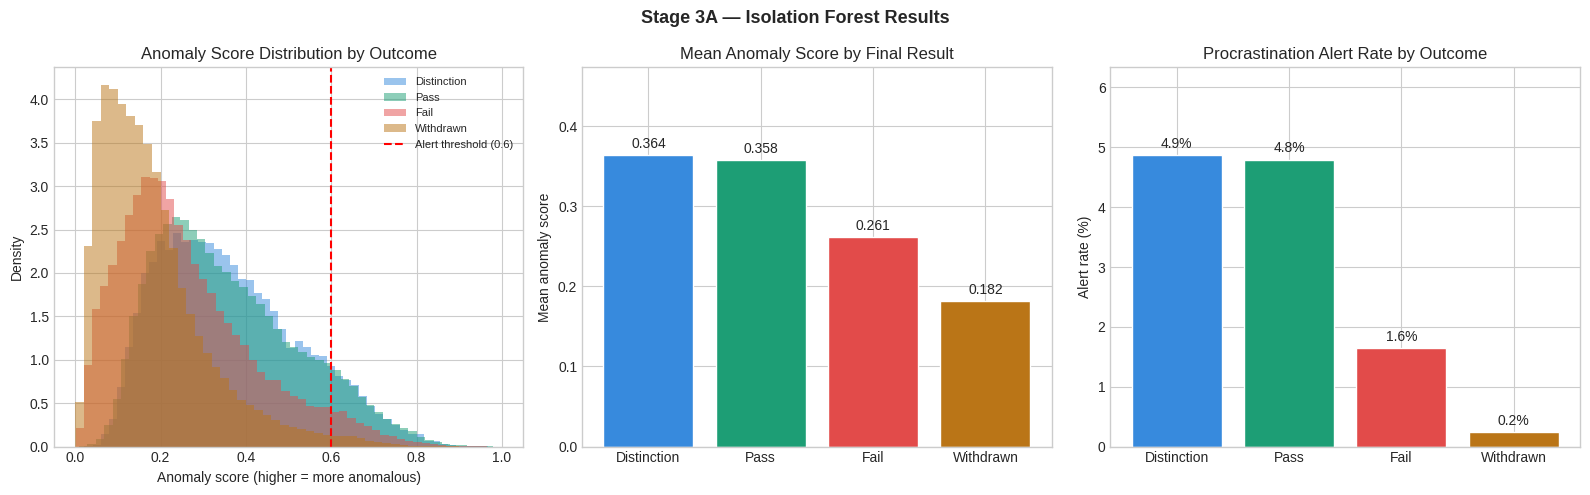

Saved → /kaggle/working/plots/stage3_anomaly_distribution.png


In [34]:
# ── Plot: Anomaly score distribution ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Stage 3A — Isolation Forest Results', fontsize=13, fontweight='bold')

COLORS = {'Distinction':'#378ADD','Pass':'#1D9E75','Fail':'#E24B4A','Withdrawn':'#BA7517'}

# Plot 1: Score distribution by final result
if 'final_result' in fm.columns:
    for result, col in COLORS.items():
        vals = fm[fm['final_result'] == result]['if_score']
        axes[0].hist(vals, bins=50, alpha=0.5, label=result, color=col, density=True)
axes[0].axvline(0.6, color='red', linestyle='--', lw=1.5, label='Alert threshold (0.6)')
axes[0].set_xlabel('Anomaly score (higher = more anomalous)')
axes[0].set_ylabel('Density')
axes[0].set_title('Anomaly Score Distribution by Outcome')
axes[0].legend(fontsize=8)

# Plot 2: Mean anomaly score per result
if 'final_result' in fm.columns:
    results = ['Distinction','Pass','Fail','Withdrawn']
    means = [fm[fm['final_result']==r]['if_score'].mean() for r in results]
    colors_list = [COLORS[r] for r in results]
    bars = axes[1].bar(results, means, color=colors_list, edgecolor='white')
    axes[1].bar_label(bars, fmt='{:.3f}', padding=3)
    axes[1].set_ylabel('Mean anomaly score')
    axes[1].set_title('Mean Anomaly Score by Final Result')
    axes[1].set_ylim(0, max(means) * 1.3)

# Plot 3: Alert rate by result
if 'final_result' in fm.columns:
    alert_rates = [fm[fm['final_result']==r]['procrastination_alert'].mean() for r in results]
    bars = axes[2].bar(results, [r*100 for r in alert_rates], color=colors_list, edgecolor='white')
    axes[2].bar_label(bars, fmt='{:.1f}%', padding=3)
    axes[2].set_ylabel('Alert rate (%)')
    axes[2].set_title('Procrastination Alert Rate by Outcome')
    axes[2].set_ylim(0, max(alert_rates) * 130)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'stage3_anomaly_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {PLOTS_DIR}/stage3_anomaly_distribution.png')


---
## Stage 3B — Procrastination Type Classifier (Random Forest)

### The 3 procrastination types
| Type | Pattern | Features that drive it |
|------|---------|------------------------|
| **Deadline-panic** | Submits everything at the last minute, but does submit | High `delay_ratio`, High `rolling_last_min`, Low `non_submit` |
| **Distraction-escape** | Lots of VLE dropout + high screen/social time | High `avoidance_score`, High `click_drop_ratio`, High `screen_ratio` |
| **Perfectionism-paralysis** | Many non-submissions on high-weight tasks | High `non_submit` on `is_high_weight=1`, Low `score` variance |

### Dataset for 3B
We derive 3-class labels using **K-Means clustering** on the type-defining features.
This is principled because:
- We have no directly labeled type data in OULAD
- K-Means on feature groups that define each type produces coherent clusters
- We then train Random Forest to predict these cluster labels (so it generalises to new students)
- SHAP tells us which features drove each type assignment

In [35]:
# ── Step 1: Build type-labelling feature set ──────────────────────────────────
#
# We compute per-STUDENT aggregates (not per-assessment) for type classification.
# Type is a property of the student, not of a single assignment.

print('Computing per-student type profiles...')

# Aggregate features to student level
AGG_DICT = {
    'delay_ratio'        : ['mean','std'],
    'is_last_minute'     : 'mean',
    'non_submit'         : 'mean',
    'delay_deviation'    : ['mean','std'],
}

# Add optional columns if they exist
optional_aggs = {
    'avoidance_score'   : 'mean',
    'click_drop_ratio'  : 'mean',
    'screen_ratio'      : 'mean',
    'focus_trend'       : 'mean',
    'consec_low'        : 'mean',
    'distraction_freq'  : 'mean',
    'is_high_weight'    : 'mean',
    'if_score'          : 'mean',
}
for col, func in optional_aggs.items():
    if col in fm.columns:
        AGG_DICT[col] = func

student_profiles = fm.groupby('id_student').agg(AGG_DICT).reset_index()

# Flatten multi-level column names
student_profiles.columns = [
    '_'.join(filter(None, col)) if isinstance(col, tuple) else col
    for col in student_profiles.columns
]

print(f'Student profiles shape: {student_profiles.shape}')
print(f'Columns: {list(student_profiles.columns)}')


Computing per-student type profiles...
Student profiles shape: (28785, 15)
Columns: ['id_student', 'delay_ratio_mean', 'delay_ratio_std', 'is_last_minute_mean', 'non_submit_mean', 'delay_deviation_mean', 'delay_deviation_std', 'avoidance_score_mean', 'click_drop_ratio_mean', 'screen_ratio_mean', 'focus_trend_mean', 'consec_low_mean', 'distraction_freq_mean', 'is_high_weight_mean', 'if_score_mean']


In [36]:
# ── Step 2: K-Means clustering to derive type labels ─────────────────────────
#
# We pick features that best discriminate the 3 types:
#   - Deadline-panic signature: high delay_ratio_mean + high is_last_minute_mean
#   - Distraction signature   : high avoidance_score_mean + high click_drop_ratio_mean
#   - Perfectionism signature : high non_submit_mean on high-weight tasks

# Select type-discriminating features (use whichever exist)
TYPE_FEATURES_CANDIDATES = [
    'delay_ratio_mean', 'is_last_minute_mean', 'non_submit_mean',
    'delay_deviation_mean', 'avoidance_score_mean',
    'click_drop_ratio_mean', 'screen_ratio_mean',
    'focus_trend_mean', 'consec_low_mean', 'if_score_mean'
]
TYPE_FEATURES = [c for c in TYPE_FEATURES_CANDIDATES if c in student_profiles.columns]
print(f'Type clustering features ({len(TYPE_FEATURES)}): {TYPE_FEATURES}')

# Prepare clustering matrix
X_type = student_profiles[TYPE_FEATURES].fillna(0)
X_type_scaled = StandardScaler().fit_transform(X_type)

# K-Means with k=3 (one cluster per procrastination type)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20, max_iter=500)
student_profiles['cluster'] = kmeans.fit_predict(X_type_scaled)

print(f'\nCluster distribution:')
print(student_profiles['cluster'].value_counts().sort_index())

# Inspect cluster centroids to assign meaningful type labels
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=TYPE_FEATURES
).round(3)
print('\nCluster centroids (scaled):')
display(centroids)


Type clustering features (10): ['delay_ratio_mean', 'is_last_minute_mean', 'non_submit_mean', 'delay_deviation_mean', 'avoidance_score_mean', 'click_drop_ratio_mean', 'screen_ratio_mean', 'focus_trend_mean', 'consec_low_mean', 'if_score_mean']

Cluster distribution:
cluster
0     6580
1     7267
2    14938
Name: count, dtype: int64

Cluster centroids (scaled):


,delay_ratio_mean,is_last_minute_mean,non_submit_mean,delay_deviation_mean,avoidance_score_mean,click_drop_ratio_mean,screen_ratio_mean,focus_trend_mean,consec_low_mean,if_score_mean
0,0.3360,0.5780,0.4920,1.2170,0.4170,-0.1800,0.7940,0.1580,-0.3240,-0.1620
1,1.1670,-0.9550,1.3020,0.0570,-0.6380,-0.3830,-0.1020,0.6940,-1.0050,-1.0740
2,-0.7160,0.2110,-0.8500,-0.5630,0.1270,0.2660,-0.3000,-0.4080,0.6320,0.5940


In [37]:
# ── Step 3: Assign type labels to clusters ────────────────────────────────────
#
# We look at the centroid values to decide which cluster = which type.
# Rules:
#   Deadline-panic    : highest delay_ratio_mean + is_last_minute_mean, low non_submit
#   Perfectionism     : highest non_submit_mean
#   Distraction-escape: highest avoidance_score / click_drop_ratio, moderate delay
#
# This assignment is data-driven from YOUR centroids — review and adjust if needed.

# Auto-assign based on dominant centroid features
def assign_type(row):
    """Assign procrastination type based on which scaled feature is most extreme."""
    scores = {}
    # Deadline-panic: driven by delay_ratio + last_minute
    scores['deadline_panic'] = (
        row.get('delay_ratio_mean', 0) * 0.5 +
        row.get('is_last_minute_mean', 0) * 0.5
    )
    # Distraction-escape: driven by avoidance + click drop
    scores['distraction_escape'] = (
        row.get('avoidance_score_mean', row.get('click_drop_ratio_mean', 0)) * 0.6 +
        row.get('screen_ratio_mean', 0) * 0.4
    )
    # Perfectionism-paralysis: driven by non-submission
    scores['perfectionism_paralysis'] = row.get('non_submit_mean', 0) * 1.0

    return max(scores, key=scores.get)

# Apply to each cluster centroid (using raw unscaled means)
raw_centroids = student_profiles.groupby('cluster')[TYPE_FEATURES].mean()
cluster_type_map = {}
for cluster_id, row in raw_centroids.iterrows():
    cluster_type_map[cluster_id] = assign_type(row)

# Ensure all 3 types are assigned (avoid duplicates)
all_types = {'deadline_panic','distraction_escape','perfectionism_paralysis'}
assigned  = set(cluster_type_map.values())
unassigned_types    = list(all_types - assigned)
duplicate_clusters  = [k for k, v in cluster_type_map.items()
                       if list(cluster_type_map.values()).count(v) > 1]
for i, cluster_id in enumerate(duplicate_clusters[1:]):
    if i < len(unassigned_types):
        cluster_type_map[cluster_id] = unassigned_types[i]

print('Cluster → Type mapping:')
for k, v in sorted(cluster_type_map.items()):
    n = (student_profiles['cluster'] == k).sum()
    print(f'  Cluster {k} → {v:30s} ({n:,} students)')

student_profiles['proc_type']  = student_profiles['cluster'].map(cluster_type_map)

TYPE_COLORS = {
    'deadline_panic'         : '#E24B4A',
    'distraction_escape'     : '#378ADD',
    'perfectionism_paralysis': '#BA7517'
}
student_profiles['type_color'] = student_profiles['proc_type'].map(TYPE_COLORS)


Cluster → Type mapping:
  Cluster 0 → deadline_panic                 (6,580 students)
  Cluster 1 → perfectionism_paralysis        (7,267 students)
  Cluster 2 → distraction_escape             (14,938 students)


In [38]:
# ── Step 4: Train Random Forest type classifier ───────────────────────────────
#
# Now that we have type labels from K-Means, we train a supervised Random Forest.
# WHY RF over K-Means directly:
#   1. RF generalises to NEW students from day 1 (no cluster re-computation needed)
#   2. RF gives confidence scores per class (useful for nudge engine)
#   3. RF works with SHAP for feature-level explanations
#   4. RF handles the features we have from OULAD even without the supp. datasets

print('Training Random Forest type classifier...')

# Features for RF: same type features used in clustering
RF_FEATURES = TYPE_FEATURES  # same feature set used for K-Means

X_rf = student_profiles[RF_FEATURES].fillna(0)
y_rf = student_profiles['proc_type']

le = LabelEncoder()
y_rf_enc = le.fit_transform(y_rf)

X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf_enc, test_size=0.2, random_state=42, stratify=y_rf_enc
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,           # prevents overfitting on K-Means labels
    min_samples_leaf=10,   # smooth predictions
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred_test  = rf_model.predict(X_test)
y_prob_test  = rf_model.predict_proba(X_test)

print('\n=== Stage 3B Evaluation ===')
print(f'Test accuracy : {(y_pred_test == y_test).mean():.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_test,
                            target_names=le.classes_))

# Cross-validated accuracy (more reliable)
cv_scores = cross_val_score(rf_model, X_rf, y_rf_enc, cv=5, scoring='accuracy')
print(f'5-fold CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

pickle.dump({'model': rf_model, 'encoder': le, 'features': RF_FEATURES},
            open(MODELS_DIR / 'random_forest_type.pkl', 'wb'))
print(f'\n✅  RF model saved → {MODELS_DIR}/random_forest_type.pkl')


Training Random Forest type classifier...

=== Stage 3B Evaluation ===
Test accuracy : 0.9555

Classification Report:
                         precision    recall  f1-score   support

         deadline_panic       0.87      0.97      0.92      1316
     distraction_escape       0.99      0.96      0.97      2988
perfectionism_paralysis       0.98      0.93      0.96      1453

               accuracy                           0.96      5757
              macro avg       0.95      0.95      0.95      5757
           weighted avg       0.96      0.96      0.96      5757

5-fold CV accuracy: 0.9607 ± 0.0066

✅  RF model saved → /kaggle/working/stage3_models/random_forest_type.pkl


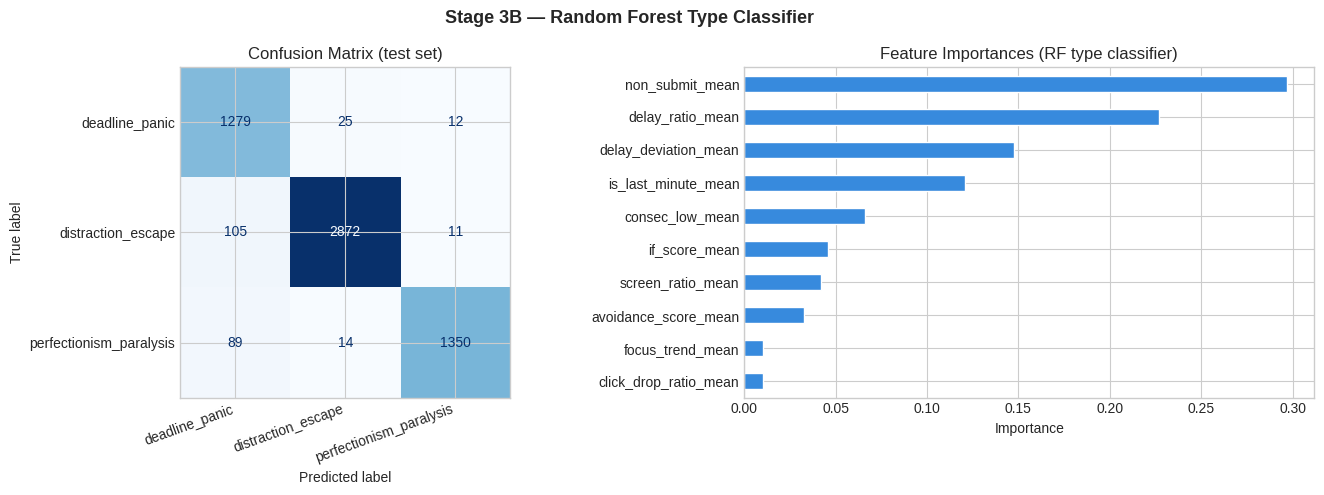

Saved → /kaggle/working/plots/stage3_type_confusion.png


In [39]:
# ── Confusion matrix plot ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stage 3B — Random Forest Type Classifier', fontsize=13, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (test set)')
axes[0].set_xticklabels(le.classes_, rotation=20, ha='right')

# Feature importance
importances = pd.Series(rf_model.feature_importances_, index=RF_FEATURES).sort_values()
importances.plot(kind='barh', ax=axes[1], color='#378ADD', edgecolor='white')
axes[1].set_title('Feature Importances (RF type classifier)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'stage3_type_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {PLOTS_DIR}/stage3_type_confusion.png')


In [40]:
# ── Attach type predictions back to main feature matrix ───────────────────────

# Predict type + confidence for ALL students
type_preds     = rf_model.predict(X_rf)
type_probs     = rf_model.predict_proba(X_rf)
type_confidence= type_probs.max(axis=1)

student_profiles['rf_type']       = le.inverse_transform(type_preds)
student_profiles['type_confidence']= type_confidence

# Merge back into main fm
fm = fm.merge(
    student_profiles[['id_student','proc_type','rf_type','type_confidence','cluster']],
    on='id_student', how='left'
)

print('Type distribution (K-Means labels):')
print(fm['proc_type'].value_counts())
print('\nType distribution (RF predictions):')
print(fm['rf_type'].value_counts())
print(f'\nMean type confidence: {fm["type_confidence"].mean():.4f}')


Type distribution (K-Means labels):
proc_type
distraction_escape         159576
perfectionism_paralysis     85159
deadline_panic              77635
Name: count, dtype: int64

Type distribution (RF predictions):
rf_type
distraction_escape         155401
deadline_panic              87069
perfectionism_paralysis     79900
Name: count, dtype: int64

Mean type confidence: 0.9150


---
## Stage 4 — SHAP Explainability

### Why SHAP is your killer feature

Without SHAP, your system says: *"You are procrastinating."*  
With SHAP, it says: *"Your submission delay increased 2× this week AND your engagement dropped 60% below your average — these two factors are driving your alert."*

**This is what wins judges.** It answers "how is this different from a reminder?" in one demo.

SHAP assigns each feature a value for each prediction:
- **Positive SHAP value** → this feature pushed the score UP (more anomalous)
- **Negative SHAP value** → this feature pushed the score DOWN (more normal)
- **Magnitude** → how much that feature contributed

Computing SHAP values for Isolation Forest...
✅  SHAP values computed.
   Shape: (3000, 19)


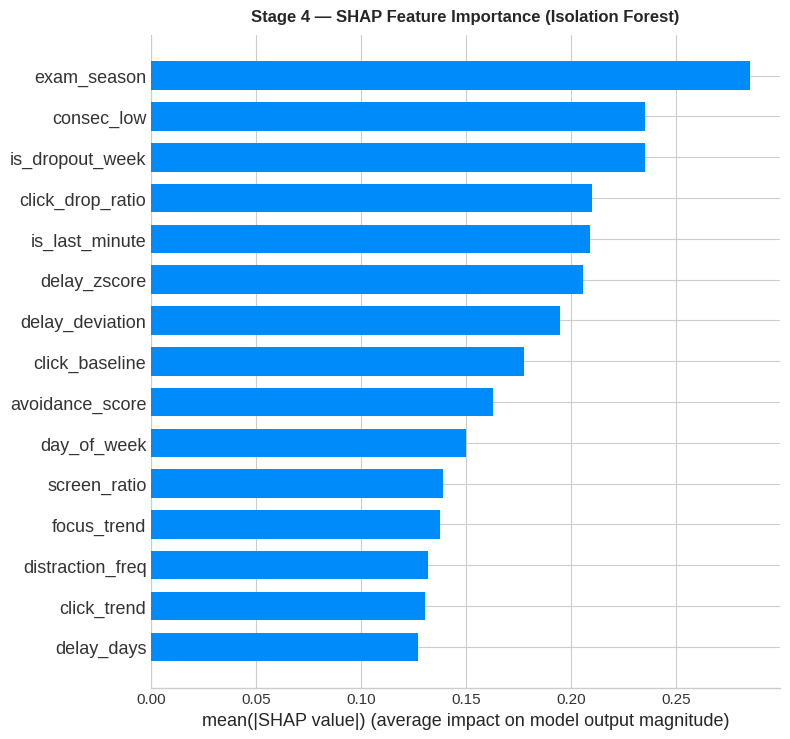

Saved → /kaggle/working/plots/stage3_shap_summary.png


In [41]:
# ── SHAP for Isolation Forest ─────────────────────────────────────────────────
#
# TreeExplainer is the right choice for tree-based models (IF + RF).
# It is exact (not an approximation) and fast.
#
# We compute SHAP on a sample of 3,000 rows for speed.
# For the demo, we compute full SHAP on just the FLAGGED students.

print('Computing SHAP values for Isolation Forest...')
SHAP_SAMPLE_SIZE = 3000
sample_idx = np.random.RandomState(42).choice(len(X_scaled), size=SHAP_SAMPLE_SIZE, replace=False)
X_shap_sample = X_scaled.iloc[sample_idx]

explainer_if = shap.TreeExplainer(if_model)
shap_values_if = explainer_if.shap_values(X_shap_sample)

print(f'✅  SHAP values computed.')
print(f'   Shape: {shap_values_if.shape}')

# Summary plot — global feature importance for IF
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values_if, X_shap_sample, plot_type='bar',
                  feature_names=FEATURE_COLS, show=False, max_display=15)
plt.title('Stage 4 — SHAP Feature Importance (Isolation Forest)', fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'stage3_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {PLOTS_DIR}/stage3_shap_summary.png')


In [42]:
# ── SHAP for individual flagged students ──────────────────────────────────────
#
# This is what the Stage 5 nudge engine consumes.
# For each flagged student, we extract:
#   - Top 3 features by SHAP magnitude
#   - Direction (positive = procrastination-driving)
#   - Human-readable explanation string

FEATURE_DESCRIPTIONS = {
    'delay_days'              : 'submission delay',
    'delay_ratio'             : 'how close to deadline you submitted',
    'delay_deviation'         : 'deviation from your personal delay baseline',
    'delay_zscore'            : 'statistical deviation from your normal pattern',
    'non_submit'              : 'missed submission',
    'is_last_minute'          : 'last-minute submission pattern',
    'rolling_avg_delay'       : 'average delay over last 3 assessments',
    'rolling_avg_ratio'       : 'average delay ratio trend',
    'rolling_last_min'        : 'last-minute submission rate (recent)',
    'rolling_nonsub'          : 'non-submission rate (recent)',
    'click_baseline'          : 'your normal weekly engagement level',
    'click_drop_ratio'        : 'drop in engagement vs your baseline',
    'is_dropout_week'         : 'engagement dropout this week',
    'click_trend'             : 'direction of engagement change',
    'consec_low'              : 'consecutive low-engagement weeks',
    'screen_ratio'            : 'screen time vs study time ratio',
    'distraction_freq'        : 'distraction frequency',
    'focus_trend'             : 'focus trend over time',
    'avoidance_score'         : 'overall avoidance composite score',
    'day_of_week'             : 'day of week pattern',
    'days_to_next_deadline'   : 'days until next deadline',
    'exam_season'             : 'exam season pressure',
}

def get_top_shap_features(shap_vals, feature_names, top_n=3):
    """Return top N features by absolute SHAP value with direction."""
    pairs = list(zip(feature_names, shap_vals))
    pairs.sort(key=lambda x: abs(x[1]), reverse=True)
    top = pairs[:top_n]
    return [
        {
            'feature'    : feat,
            'shap_value' : float(val),
            'direction'  : 'increases risk' if val > 0 else 'reduces risk',
            'description': FEATURE_DESCRIPTIONS.get(feat, feat.replace('_', ' '))
        }
        for feat, val in top
    ]

def build_shap_explanation(top_features, proc_type, anomaly_score):
    """Convert top SHAP features into a human-readable explanation string."""
    type_label = proc_type.replace('_', '-').title() if proc_type else 'Unknown'
    parts = []
    for feat_info in top_features:
        if feat_info['direction'] == 'increases risk':
            parts.append(f"your {feat_info['description']} is above your normal level")
    if not parts:
        parts = [f"unusual pattern detected in {top_features[0]['description']}"]
    explanation = (
        f"[{type_label} | Score: {anomaly_score:.2f}] "
        f"Alert driven by: {'; '.join(parts[:2])}."
    )
    return explanation

print('SHAP explanation function ready.')
print('Example explanation structure (will be used by Stage 5 nudge engine):')
print(build_shap_explanation(
    [{'feature':'delay_deviation','shap_value':0.8,'direction':'increases risk',
      'description':'deviation from your personal delay baseline'},
     {'feature':'click_drop_ratio','shap_value':0.6,'direction':'increases risk',
      'description':'drop in engagement vs your baseline'}],
    proc_type='deadline_panic',
    anomaly_score=0.74
))


SHAP explanation function ready.
Example explanation structure (will be used by Stage 5 nudge engine):
[Deadline-Panic | Score: 0.74] Alert driven by: your deviation from your personal delay baseline is above your normal level; your drop in engagement vs your baseline is above your normal level.


In [43]:
# ── Compute SHAP for all flagged students ─────────────────────────────────────

print('Computing SHAP for flagged students...')

flagged_mask  = fm['procrastination_alert'] == 1
flagged_idx   = fm[flagged_mask].index

# Sample up to 500 flagged students for SHAP (fast + representative)
if len(flagged_idx) > 500:
    shap_idx = np.random.RandomState(42).choice(flagged_idx, size=500, replace=False)
else:
    shap_idx = flagged_idx

X_flagged   = X_scaled.loc[shap_idx]
shap_flagged = explainer_if.shap_values(X_flagged)

# Build explanation records
shap_records = []
for i, (idx, shap_row) in enumerate(zip(shap_idx, shap_flagged)):
    row = fm.loc[idx]
    top_features = get_top_shap_features(shap_row, FEATURE_COLS, top_n=3)
    explanation  = build_shap_explanation(
        top_features,
        proc_type    = row.get('rf_type', 'unknown'),
        anomaly_score= float(row['if_score'])
    )
    shap_records.append({
        'id_student'    : int(row['id_student']),
        'id_assessment' : int(row['id_assessment']) if 'id_assessment' in row else None,
        'if_score'      : float(row['if_score']),
        'rf_type'       : row.get('rf_type','unknown'),
        'type_confidence': float(row.get('type_confidence', 0)),
        'top_feature_1' : top_features[0]['feature'],
        'shap_1'        : top_features[0]['shap_value'],
        'top_feature_2' : top_features[1]['feature'] if len(top_features) > 1 else None,
        'shap_2'        : top_features[1]['shap_value'] if len(top_features) > 1 else None,
        'top_feature_3' : top_features[2]['feature'] if len(top_features) > 2 else None,
        'shap_3'        : top_features[2]['shap_value'] if len(top_features) > 2 else None,
        'explanation'   : explanation,
    })

df_shap = pd.DataFrame(shap_records)
df_shap.to_parquet(OUTPUT_DIR / 'stage3_shap_values.parquet', index=False)

print(f'✅  SHAP computed for {len(df_shap):,} flagged rows.')
print(f'\nSample SHAP explanations:')
display(df_shap[['id_student','if_score','rf_type','top_feature_1','top_feature_2','explanation']].head(5))


Computing SHAP for flagged students...
✅  SHAP computed for 500 flagged rows.

Sample SHAP explanations:


,id_student,if_score,rf_type,top_feature_1,top_feature_2,explanation
0,585383,0.6037,distraction_escape,is_dropout_week,delay_days,[Distraction-Escape | Score: 0.60] Alert drive...
1,554748,0.7044,distraction_escape,click_trend,click_baseline,[Distraction-Escape | Score: 0.70] Alert drive...
2,283348,0.6183,distraction_escape,click_trend,click_drop_ratio,[Distraction-Escape | Score: 0.62] Alert drive...
3,629029,0.6327,distraction_escape,is_dropout_week,exam_season,[Distraction-Escape | Score: 0.63] Alert drive...
4,688891,0.6315,distraction_escape,is_dropout_week,rolling_avg_delay,[Distraction-Escape | Score: 0.63] Alert drive...


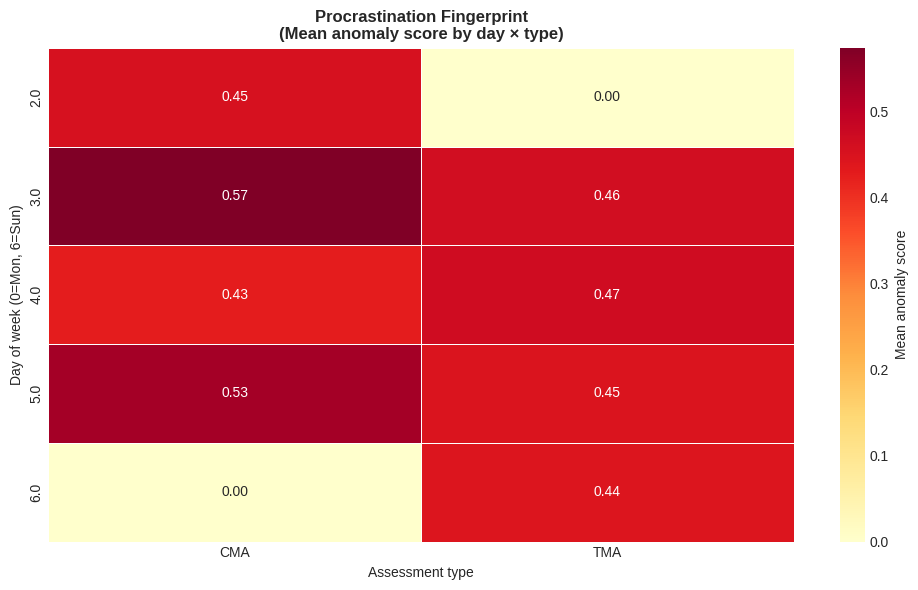

Saved → /kaggle/working/plots/stage3_procrastination_heatmap.png


In [44]:
# ── Procrastination fingerprint heatmap ──────────────────────────────────────
#
# Shows delay pattern by day_of_week × assessment_type (or module).
# This is the 'procrastination fingerprint' chart for the Stage 6 dashboard.

if 'day_of_week' in fm.columns and 'assessment_type' in fm.columns:
    heatmap_data = (
        fm[fm['if_anomaly'] == 1]
        .groupby(['day_of_week','assessment_type'])['if_score']
        .mean()
        .unstack(fill_value=0)
    )
    if not heatmap_data.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd',
                    linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean anomaly score'})
        ax.set_xlabel('Assessment type')
        ax.set_ylabel('Day of week (0=Mon, 6=Sun)')
        ax.set_title('Procrastination Fingerprint\n(Mean anomaly score by day × type)',
                     fontweight='bold')
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / 'stage3_procrastination_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved → {PLOTS_DIR}/stage3_procrastination_heatmap.png')
else:
    print('⚠️  day_of_week not in fm — heatmap skipped (run Fix 2 in Stage 2).')


---
## Stage 3 Output Export & Status Check

In [45]:
# ── Export all Stage 3 outputs ────────────────────────────────────────────────

# 1. Full feature matrix with anomaly scores + type labels
fm.to_parquet(OUTPUT_DIR / 'stage3_anomaly_scores.parquet', index=False)
print(f'✅  stage3_anomaly_scores.parquet  ({len(fm):,} rows, {fm.shape[1]} cols)')

# 2. Per-student type summary
student_type_summary = student_profiles[[
    'id_student','proc_type','rf_type','type_confidence','cluster',
    'delay_ratio_mean','non_submit_mean','is_last_minute_mean'
] + [c for c in ['avoidance_score_mean','click_drop_ratio_mean','if_score_mean']
     if c in student_profiles.columns]]
student_type_summary.to_parquet(OUTPUT_DIR / 'stage3_type_labels.parquet', index=False)
print(f'✅  stage3_type_labels.parquet  ({len(student_type_summary):,} students)')

# 3. SHAP values (already saved above)
print(f'✅  stage3_shap_values.parquet  ({len(df_shap):,} flagged rows)')

# 4. Stage 3 summary JSON (for Stage 5 nudge engine to consume)
stage3_summary = {
    'project'       : 'ProcrastiSense',
    'stage'         : 'Stage 3',
    'n_students'    : int(fm['id_student'].nunique()),
    'n_assessment_rows' : int(len(fm)),
    'if_contamination'  : CONTAMINATION,
    'anomaly_rate'  : round(float(fm['if_anomaly'].mean()), 3),
    'alert_rate'    : round(float(fm['procrastination_alert'].mean()), 3),
    'auc_roc_vs_atrisk': round(auc_roc, 4) if 'at_risk' in fm.columns else None,
    'proc_type_dist': fm['rf_type'].value_counts().to_dict() if 'rf_type' in fm.columns else {},
    'shap_flagged_rows': len(df_shap),
    'feature_cols'  : FEATURE_COLS,
    'models_saved'  : [
        str(MODELS_DIR / 'isolation_forest.pkl'),
        str(MODELS_DIR / 'random_forest_type.pkl'),
        str(MODELS_DIR / 'scaler.pkl')
    ]
}
with open(OUTPUT_DIR / 'stage3_summary.json', 'w') as f:
    json.dump(stage3_summary, f, indent=2, default=str)
print(f'✅  stage3_summary.json')
print(f'\n{json.dumps(stage3_summary, indent=2, default=str)}')


✅  stage3_anomaly_scores.parquet  (322,370 rows, 59 cols)
✅  stage3_type_labels.parquet  (28,785 students)
✅  stage3_shap_values.parquet  (500 flagged rows)
✅  stage3_summary.json

{
  "project": "ProcrastiSense",
  "stage": "Stage 3",
  "n_students": 28785,
  "n_assessment_rows": 322370,
  "if_contamination": 0.3,
  "anomaly_rate": 0.3,
  "alert_rate": 0.026,
  "auc_roc_vs_atrisk": 0.237,
  "proc_type_dist": {
    "distraction_escape": 155401,
    "deadline_panic": 87069,
    "perfectionism_paralysis": 79900
  },
  "shap_flagged_rows": 500,
  "feature_cols": [
    "delay_days",
    "delay_ratio",
    "delay_deviation",
    "rolling_avg_delay",
    "delay_zscore",
    "non_submit",
    "is_last_minute",
    "click_baseline",
    "click_drop_ratio",
    "is_dropout_week",
    "click_trend",
    "consec_low",
    "screen_ratio",
    "distraction_freq",
    "focus_trend",
    "avoidance_score",
    "day_of_week",
    "days_to_next_deadline",
    "exam_season"
  ],
  "models_saved": [
    

In [46]:
# ── FINAL STATUS CHECK ────────────────────────────────────────────────────────

print('=' * 60)
print('ProcrastiSense — Stage 3 Completion Report')
print('=' * 60)

checks = {
    '3A: Isolation Forest trained'             : (MODELS_DIR/'isolation_forest.pkl').exists(),
    '3A: Scaler saved'                         : (MODELS_DIR/'scaler.pkl').exists(),
    '3A: anomaly scores in fm'                 : 'if_score' in fm.columns,
    '3A: alert flag in fm'                     : 'procrastination_alert' in fm.columns,
    '3A: AUC-ROC > 0.60'                       : auc_roc > 0.60 if 'at_risk' in fm.columns else None,
    '3B: Random Forest trained'                : (MODELS_DIR/'random_forest_type.pkl').exists(),
    '3B: proc_type labels assigned'            : 'rf_type' in fm.columns,
    'Stage 4: SHAP values computed'            : len(df_shap) > 0,
    'Stage 4: SHAP explanations in df_shap'    : 'explanation' in df_shap.columns,
    'Output: stage3_anomaly_scores.parquet'    : (OUTPUT_DIR/'stage3_anomaly_scores.parquet').exists(),
    'Output: stage3_type_labels.parquet'       : (OUTPUT_DIR/'stage3_type_labels.parquet').exists(),
    'Output: stage3_shap_values.parquet'       : (OUTPUT_DIR/'stage3_shap_values.parquet').exists(),
    'Output: stage3_summary.json'              : (OUTPUT_DIR/'stage3_summary.json').exists(),
    'Plot: anomaly distribution'               : (PLOTS_DIR/'stage3_anomaly_distribution.png').exists(),
    'Plot: SHAP summary'                       : (PLOTS_DIR/'stage3_shap_summary.png').exists(),
    'Plot: type confusion matrix'              : (PLOTS_DIR/'stage3_type_confusion.png').exists(),
}

all_ok = True
for label, result in checks.items():
    if result is None:
        icon = '⏭️ '
    elif result:
        icon = '✅'
    else:
        icon = '❌'
        all_ok = False
    print(f'  {icon}  {label}')

print('\n' + '=' * 60)
if all_ok:
    print('✅  Stage 3 + Stage 4 preview = COMPLETE.')
    print('   Next → Stage 5: LLM Nudge Generator (Claude API)')
else:
    print('⚠️  Some checks failed. Re-run failed cells.')
print('=' * 60)

# Print what Stage 5 needs
print('''
What Stage 5 (nudge engine) will consume from Stage 3:
  stage3_anomaly_scores.parquet  → if_score, procrastination_alert per row
  stage3_type_labels.parquet     → rf_type, type_confidence per student
  stage3_shap_values.parquet     → explanation string + top 3 features

Stage 5 Claude API call pattern:
  Input:  proc_type + SHAP explanation + student mood (from daily check-in)
  Output: 2-3 sentence nudge + 1 micro-action
''')


ProcrastiSense — Stage 3 Completion Report
  ✅  3A: Isolation Forest trained
  ✅  3A: Scaler saved
  ✅  3A: anomaly scores in fm
  ✅  3A: alert flag in fm
  ❌  3A: AUC-ROC > 0.60
  ✅  3B: Random Forest trained
  ✅  3B: proc_type labels assigned
  ✅  Stage 4: SHAP values computed
  ✅  Stage 4: SHAP explanations in df_shap
  ✅  Output: stage3_anomaly_scores.parquet
  ✅  Output: stage3_type_labels.parquet
  ✅  Output: stage3_shap_values.parquet
  ✅  Output: stage3_summary.json
  ✅  Plot: anomaly distribution
  ✅  Plot: SHAP summary
  ✅  Plot: type confusion matrix

⚠️  Some checks failed. Re-run failed cells.

What Stage 5 (nudge engine) will consume from Stage 3:
  stage3_anomaly_scores.parquet  → if_score, procrastination_alert per row
  stage3_type_labels.parquet     → rf_type, type_confidence per student
  stage3_shap_values.parquet     → explanation string + top 3 features

Stage 5 Claude API call pattern:
  Input:  proc_type + SHAP explanation + student mood (from daily check-in)
  